In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ecommerce_dirty_dataset.csv")

In [3]:
df

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,NaN,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100495,79219,2023-10-02,2023-10-03,4301,Corporate,East,Odisha,Furniture,Chair,Chair Product 52,2667.00,1,0.00,829.68,185.0,Credit Card
100496,36298,2023-06-02,2023-06-05,4770,Consumer,North,Haryana,Furniture,Table,Table Product 2,56026.25,5,0.05,8928.97,217.0,Credit Card
100497,80041,2023-03-28,2023-04-02,3689,Consumer,East,Bihar,Furniture,Chair,Chair Product 55,22953.00,5,0.30,6327.46,95.0,Debit Card
100498,15667,2023-07-18,2023-07-20,1380,Corporate,West,Gujarat,Electronics,Laptop,Laptop Product 172,289241.75,5,0.05,106184.34,462.0,Credit Card


# Phase 1- DATA CLEANING

###### 1. Basic Inspection

In [4]:
df.head()

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.0,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.0,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.1,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.0,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,NaN,North,Haryana,Clothing,Women,Women Product 50,6807.0,3,0.00,2653.83,94.0,Debit Card


In [5]:
df.columns

Index(['Order_ID', 'Order_Date', 'Ship_Date', 'Customer_ID',
       'Customer_Segment', 'Region', 'State', 'Product_Category',
       'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping_Cost', 'Payment_Mode'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100500 entries, 0 to 100499
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order_ID          100500 non-null  int64  
 1   Order_Date        100500 non-null  object 
 2   Ship_Date         100500 non-null  object 
 3   Customer_ID       100500 non-null  int64  
 4   Customer_Segment  97481 non-null   object 
 5   Region            100500 non-null  object 
 6   State             100500 non-null  object 
 7   Product_Category  100500 non-null  object 
 8   Sub_Category      100500 non-null  object 
 9   Product_Name      100500 non-null  object 
 10  Sales             100500 non-null  float64
 11  Quantity          100500 non-null  int64  
 12  Discount          100500 non-null  float64
 13  Profit            97481 non-null   float64
 14  Shipping_Cost     97494 non-null   float64
 15  Payment_Mode      100500 non-null  object 
dtypes: float64(4), int64

In [7]:
df.shape

(100500, 16)

In [8]:
df.dtypes

Order_ID              int64
Order_Date           object
Ship_Date            object
Customer_ID           int64
Customer_Segment     object
Region               object
State                object
Product_Category     object
Sub_Category         object
Product_Name         object
Sales               float64
Quantity              int64
Discount            float64
Profit              float64
Shipping_Cost       float64
Payment_Mode         object
dtype: object

In [9]:
df.duplicated

<bound method DataFrame.duplicated of         Order_ID  Order_Date   Ship_Date  Customer_ID Customer_Segment Region  \
0              1  2022-04-13  2022-04-14         1992         Consumer   East   
1              2  2023-03-12  2023-03-13         4347        Corporate   East   
2              3  2022-09-28  2022-10-04         2195        Corporate   West   
3              4  2022-04-17  2022-04-21         3425         Consumer  South   
4              5  2022-03-13  2022-03-20         2967              NaN  North   
...          ...         ...         ...          ...              ...    ...   
100495     79219  2023-10-02  2023-10-03         4301        Corporate   East   
100496     36298  2023-06-02  2023-06-05         4770         Consumer  North   
100497     80041  2023-03-28  2023-04-02         3689         Consumer   East   
100498     15667  2023-07-18  2023-07-20         1380        Corporate   West   
100499      1917  2023-07-07  2023-07-08         4457         Consumer 

# 2️. Handle Missing Values

In [10]:
# Identifying missing values
df.isnull()

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100495,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
100496,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
100497,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
100498,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
df.isnull().sum()

Order_ID               0
Order_Date             0
Ship_Date              0
Customer_ID            0
Customer_Segment    3019
Region                 0
State                  0
Product_Category       0
Sub_Category           0
Product_Name           0
Sales                  0
Quantity               0
Discount               0
Profit              3019
Shipping_Cost       3006
Payment_Mode           0
dtype: int64

# 3️. Remove Duplicates

In [12]:
# dropping duplicates
df = df.drop_duplicates()

In [13]:
df 

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,NaN,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI
100455,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,Electronics,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,248.0,Credit Card


In [14]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [15]:
df.isna()

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
100439,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
100451,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
100455,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [16]:
df.duplicated().sum()

0

In [17]:
df = df.dropna(subset=["Order_ID"])


In [18]:
df

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,NaN,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI
100455,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,Electronics,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,248.0,Credit Card


In [19]:
df.describe()

,Order_ID,Customer_ID,Sales,Quantity,Discount,Profit,Shipping_Cost
count,100019.000000,100019.000000,100019.000000,100019.000000,100019.000000,97019.000000,97021.000000
mean,49999.828063,3000.266839,51350.807173,2.997860,0.120223,13115.547546,285.430597
std,28867.896326,1153.229108,68914.410905,1.414855,0.113526,21747.779245,337.979471
min,1.000000,1000.000000,-5000.000000,1.000000,0.000000,36.040000,50.000000
25%,24998.500000,2004.000000,7828.400000,2.000000,0.050000,1761.695000,163.000000
50%,50000.000000,3000.000000,21259.200000,3.000000,0.100000,5101.150000,276.000000
75%,75000.500000,3997.000000,63423.775000,4.000000,0.200000,15576.080000,388.000000
max,100000.000000,4999.000000,399965.000000,5.000000,0.900000,500000.000000,10000.000000


# 4️. Fix Data Types

In [20]:
# Changing Order_date to datetime datatype
df["Order_Date"] = pd.to_datetime(df["Order_Date"],format = "mixed")

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100019 entries, 0 to 100496
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order_ID          100019 non-null  int64         
 1   Order_Date        100019 non-null  datetime64[ns]
 2   Ship_Date         100019 non-null  object        
 3   Customer_ID       100019 non-null  int64         
 4   Customer_Segment  97019 non-null   object        
 5   Region            100019 non-null  object        
 6   State             100019 non-null  object        
 7   Product_Category  100019 non-null  object        
 8   Sub_Category      100019 non-null  object        
 9   Product_Name      100019 non-null  object        
 10  Sales             100019 non-null  float64       
 11  Quantity          100019 non-null  int64         
 12  Discount          100019 non-null  float64       
 13  Profit            97019 non-null   float64       
 14  Shipping_

In [22]:
# Changing Ship_date to datetime datatype
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"],format = "mixed")

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100019 entries, 0 to 100496
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order_ID          100019 non-null  int64         
 1   Order_Date        100019 non-null  datetime64[ns]
 2   Ship_Date         100019 non-null  datetime64[ns]
 3   Customer_ID       100019 non-null  int64         
 4   Customer_Segment  97019 non-null   object        
 5   Region            100019 non-null  object        
 6   State             100019 non-null  object        
 7   Product_Category  100019 non-null  object        
 8   Sub_Category      100019 non-null  object        
 9   Product_Name      100019 non-null  object        
 10  Sales             100019 non-null  float64       
 11  Quantity          100019 non-null  int64         
 12  Discount          100019 non-null  float64       
 13  Profit            97019 non-null   float64       
 14  Shipping_

In [24]:
# Applying mode on customer segment
df1= df.copy()

In [25]:
df1["Customer_Segment"] = df["Customer_Segment"].fillna(df["Customer_Segment"].mode()[0])

In [26]:
df1

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI
100455,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,Electronics,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,248.0,Credit Card


In [27]:
# Time taken for delivery
df1["Delivery_time"] = ((df["Ship_Date"]) - (df["Order_Date"])).dt.days

In [28]:
df1

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery,1
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery,1
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card,6
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery,4
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card,5
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery,1
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI,7
100455,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,Electronics,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,248.0,Credit Card,6


In [29]:
# Checking which column has null values along with their sum
df1.isnull().sum()

Order_ID               0
Order_Date             0
Ship_Date              0
Customer_ID            0
Customer_Segment       0
Region                 0
State                  0
Product_Category       0
Sub_Category           0
Product_Name           0
Sales                  0
Quantity               0
Discount               0
Profit              3000
Shipping_Cost       2998
Payment_Mode           0
Delivery_time          0
dtype: int64

In [30]:
# I don't want any effect on data by removing those null-valued rows so,
# As outliers are present in Profit so here I've been used median to fix Profit column
# Replacing null values with median in Shipping_cost

In [31]:
df1["Profit"] = df["Profit"].fillna(df["Profit"].median())

In [32]:
df1

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery,1
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery,1
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card,6
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery,4
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card,5
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery,1
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI,7
100455,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,Electronics,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,248.0,Credit Card,6


In [33]:
df1["Shipping_Cost"] = df["Shipping_Cost"].fillna(df["Shipping_Cost"].median())

In [34]:
df1.isnull().sum()

Order_ID            0
Order_Date          0
Ship_Date           0
Customer_ID         0
Customer_Segment    0
Region              0
State               0
Product_Category    0
Sub_Category        0
Product_Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping_Cost       0
Payment_Mode        0
Delivery_time       0
dtype: int64

In [35]:
df1

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,328.0,Cash on Delivery,1
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery,1
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,348.0,Credit Card,6
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery,4
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,94.0,Debit Card,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card,5
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery,1
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI,7
100455,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,Electronics,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,248.0,Credit Card,6


# 5️. Logical Validation

In [36]:
# Ship_Date earlier than Order_Date
# checking whether the order date is earlier than ship date

In [37]:
df1[df1["Order_Date"] > df1["Ship_Date"]]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
58,59,2022-04-02,2022-03-31,2571,Corporate,West,Rajasthan,Furniture,Chair,Chair Product 187,33548.80,4,0.20,5101.15,336.0,Debit Card,-2
387,388,2023-05-21,2023-05-19,1735,Home Office,East,Bihar,Electronics,Laptop,Laptop Product 130,173593.50,5,0.05,60824.90,440.0,Debit Card,-2
657,658,2022-04-27,2022-04-25,4586,Home Office,South,Tamil Nadu,Electronics,Accessories,Accessories Product 62,93864.75,3,0.05,17035.33,313.0,UPI,-2
732,733,2023-11-20,2023-11-18,2464,Corporate,East,West Bengal,Clothing,Men,Men Product 76,15990.20,4,0.15,4520.68,327.0,Credit Card,-2
1587,1588,2022-08-12,2022-08-10,2328,Corporate,West,Maharashtra,Electronics,Mobile,Mobile Product 125,189434.40,4,0.15,26407.61,221.0,Debit Card,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99963,99964,2022-10-02,2022-09-30,1478,Consumer,South,Karnataka,Furniture,Table,Table Product 169,25411.20,3,0.20,8290.54,248.0,Cash on Delivery,-2
100068,17251,2022-03-02,2022-02-28,2209,Home Office,North,Haryana,Clothing,Kids,Kids Product 8,3717.00,2,0.10,1079.06,371.0,Debit Card,-2
100250,16460,2023-02-28,2023-02-26,4563,Consumer,East,West Bengal,Furniture,Sofa,Sofa Product 53,7024.50,1,0.10,1947.89,418.0,Debit Card,-2
100285,24425,2022-06-12,2022-06-10,4611,Consumer,West,Rajasthan,Furniture,Sofa,Sofa Product 131,9116.00,1,0.00,3340.11,276.0,Debit Card,-2


In [38]:
df1[df1["Delivery_time"] < 0]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
58,59,2022-04-02,2022-03-31,2571,Corporate,West,Rajasthan,Furniture,Chair,Chair Product 187,33548.80,4,0.20,5101.15,336.0,Debit Card,-2
387,388,2023-05-21,2023-05-19,1735,Home Office,East,Bihar,Electronics,Laptop,Laptop Product 130,173593.50,5,0.05,60824.90,440.0,Debit Card,-2
657,658,2022-04-27,2022-04-25,4586,Home Office,South,Tamil Nadu,Electronics,Accessories,Accessories Product 62,93864.75,3,0.05,17035.33,313.0,UPI,-2
732,733,2023-11-20,2023-11-18,2464,Corporate,East,West Bengal,Clothing,Men,Men Product 76,15990.20,4,0.15,4520.68,327.0,Credit Card,-2
1587,1588,2022-08-12,2022-08-10,2328,Corporate,West,Maharashtra,Electronics,Mobile,Mobile Product 125,189434.40,4,0.15,26407.61,221.0,Debit Card,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99963,99964,2022-10-02,2022-09-30,1478,Consumer,South,Karnataka,Furniture,Table,Table Product 169,25411.20,3,0.20,8290.54,248.0,Cash on Delivery,-2
100068,17251,2022-03-02,2022-02-28,2209,Home Office,North,Haryana,Clothing,Kids,Kids Product 8,3717.00,2,0.10,1079.06,371.0,Debit Card,-2
100250,16460,2023-02-28,2023-02-26,4563,Consumer,East,West Bengal,Furniture,Sofa,Sofa Product 53,7024.50,1,0.10,1947.89,418.0,Debit Card,-2
100285,24425,2022-06-12,2022-06-10,4611,Consumer,West,Rajasthan,Furniture,Sofa,Sofa Product 131,9116.00,1,0.00,3340.11,276.0,Debit Card,-2


In [39]:
# Here I've reversed order date and ship date where Order date is greater than ship date 
df1.loc[df1["Order_Date"] > df1["Ship_Date"],
        ["Order_Date","Ship_Date"]] = (df1.loc[df1["Order_Date"] > df1["Ship_Date"],
                                               ["Ship_Date","Order_Date"]].values)

In [40]:
# Confirmation
df1[df1["Delivery_time"] < 0]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
58,59,2022-03-31,2022-04-02,2571,Corporate,West,Rajasthan,Furniture,Chair,Chair Product 187,33548.80,4,0.20,5101.15,336.0,Debit Card,-2
387,388,2023-05-19,2023-05-21,1735,Home Office,East,Bihar,Electronics,Laptop,Laptop Product 130,173593.50,5,0.05,60824.90,440.0,Debit Card,-2
657,658,2022-04-25,2022-04-27,4586,Home Office,South,Tamil Nadu,Electronics,Accessories,Accessories Product 62,93864.75,3,0.05,17035.33,313.0,UPI,-2
732,733,2023-11-18,2023-11-20,2464,Corporate,East,West Bengal,Clothing,Men,Men Product 76,15990.20,4,0.15,4520.68,327.0,Credit Card,-2
1587,1588,2022-08-10,2022-08-12,2328,Corporate,West,Maharashtra,Electronics,Mobile,Mobile Product 125,189434.40,4,0.15,26407.61,221.0,Debit Card,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99963,99964,2022-09-30,2022-10-02,1478,Consumer,South,Karnataka,Furniture,Table,Table Product 169,25411.20,3,0.20,8290.54,248.0,Cash on Delivery,-2
100068,17251,2022-02-28,2022-03-02,2209,Home Office,North,Haryana,Clothing,Kids,Kids Product 8,3717.00,2,0.10,1079.06,371.0,Debit Card,-2
100250,16460,2023-02-26,2023-02-28,4563,Consumer,East,West Bengal,Furniture,Sofa,Sofa Product 53,7024.50,1,0.10,1947.89,418.0,Debit Card,-2
100285,24425,2022-06-10,2022-06-12,4611,Consumer,West,Rajasthan,Furniture,Sofa,Sofa Product 131,9116.00,1,0.00,3340.11,276.0,Debit Card,-2


In [41]:
# In the above code after replacing the order date and ship date which are inappropriate 
# Then I've Checked it for confirmation again there are errors.
# Solution for this is to execute the below code 

In [42]:
df1["Delivery_time"] = ((df1["Ship_Date"]) - (df1["Order_Date"])).dt.days

In [43]:
df1[df1["Delivery_time"] < 0]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time


###### •	Negative Sales

In [44]:
# Negative Sales

In [45]:
df1[df1["Sales"] <= 0]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
470,471,2022-07-23,2022-07-25,4375,Corporate,East,Odisha,Electronics,Accessories,Accessories Product 54,-5000.0,5,0.15,75466.83,428.0,UPI,2
1706,1707,2022-03-25,2022-03-26,1749,Consumer,East,West Bengal,Furniture,Chair,Chair Product 160,-5000.0,2,0.10,8349.24,58.0,UPI,1
3627,3628,2023-04-01,2023-04-06,1171,Home Office,North,Haryana,Electronics,Laptop,Laptop Product 182,-5000.0,5,0.05,51986.61,207.0,Cash on Delivery,5
4186,4187,2022-04-10,2022-04-17,4931,Consumer,West,Maharashtra,Clothing,Women,Women Product 177,-5000.0,2,0.00,2105.71,443.0,UPI,7
6067,6068,2023-03-18,2023-03-22,2880,Consumer,North,Haryana,Clothing,Men,Men Product 184,-5000.0,3,0.00,2326.83,239.0,Debit Card,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97644,97645,2023-10-08,2023-10-13,1794,Home Office,North,Punjab,Electronics,Accessories,Accessories Product 149,-5000.0,2,0.05,21369.92,250.0,Debit Card,5
98510,98511,2022-04-01,2022-04-05,3314,Consumer,North,Punjab,Clothing,Men,Men Product 164,-5000.0,4,0.05,4090.01,296.0,Credit Card,4
99372,99373,2022-01-30,2022-01-31,4328,Corporate,West,Gujarat,Clothing,Men,Men Product 65,-5000.0,5,0.00,1627.84,109.0,Debit Card,1
99757,99758,2022-09-26,2022-09-30,4199,Consumer,North,Haryana,Clothing,Women,Women Product 72,-5000.0,4,0.05,2350.66,130.0,Debit Card,4


In [46]:
df1[df1["Sales"] < 0][["Sales","Profit","Discount","Shipping_Cost"]].head()

,Sales,Profit,Discount,Shipping_Cost
470,-5000.0,75466.83,0.15,428.0
1706,-5000.0,8349.24,0.10,58.0
3627,-5000.0,51986.61,0.05,207.0
4186,-5000.0,2105.71,0.00,443.0
6067,-5000.0,2326.83,0.00,239.0


In [47]:
df1[df1["Sales"] < 0][["Sales","Profit","Discount","Shipping_Cost"]].sample(7)

,Sales,Profit,Discount,Shipping_Cost
42936,-5000.0,4979.24,0.00,347.0
98510,-5000.0,4090.01,0.05,296.0
44414,-5000.0,60206.29,0.10,494.0
61078,-5000.0,3496.34,0.20,480.0
47926,-5000.0,1143.17,0.10,432.0
92814,-5000.0,5101.15,0.20,484.0
93255,-5000.0,8588.10,0.15,453.0


In [48]:
# Checking the exact count of negative sales
df1[df1["Sales"] < 0]["Sales"].value_counts()

Sales
-5000.0    150
Name: count, dtype: int64

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100019 entries, 0 to 100496
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order_ID          100019 non-null  int64         
 1   Order_Date        100019 non-null  datetime64[ns]
 2   Ship_Date         100019 non-null  datetime64[ns]
 3   Customer_ID       100019 non-null  int64         
 4   Customer_Segment  97019 non-null   object        
 5   Region            100019 non-null  object        
 6   State             100019 non-null  object        
 7   Product_Category  100019 non-null  object        
 8   Sub_Category      100019 non-null  object        
 9   Product_Name      100019 non-null  object        
 10  Sales             100019 non-null  float64       
 11  Quantity          100019 non-null  int64         
 12  Discount          100019 non-null  float64       
 13  Profit            97019 non-null   float64       
 14  Shipping_

In [50]:
# Sales values which are containing -5000 are replaced with NA
df1.loc[df1["Sales"] == -5000, "Sales"] = pd.NA

In [51]:
# Replacing those NA values with median because of outliers
df1["Sales"] = df1["Sales"].fillna(df1["Sales"].median())

In [52]:
df1["Sales"].sample(5)

4415      12313.8
47647     11808.0
67909      5451.9
48943     25620.0
69167    232704.5
Name: Sales, dtype: float64

In [53]:
# Checking
df1[df1["Sales"] < 0].value_counts()

Series([], Name: count, dtype: int64)

###### •	Extremely high Discount (>80%)

In [54]:
# Extremely high Discount (>80%)

In [55]:
df1[df1["Discount"] > 0.8]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
516,517,2023-05-14,2023-05-18,1820,Corporate,East,West Bengal,Clothing,Kids,Kids Product 154,19679.25,5,0.9,6259.19,474.0,UPI,4
1126,1127,2023-04-07,2023-04-08,1548,Corporate,North,Delhi,Furniture,Table,Table Product 42,42547.50,5,0.9,6770.94,368.0,UPI,1
1494,1495,2023-01-11,2023-01-15,3962,Corporate,North,Punjab,Furniture,Sofa,Sofa Product 176,12301.55,1,0.9,4431.19,482.0,Credit Card,4
2123,2124,2023-06-23,2023-06-27,4468,Corporate,North,Haryana,Furniture,Sofa,Sofa Product 57,4675.00,1,0.9,1471.27,162.0,UPI,4
3329,3330,2023-03-05,2023-03-11,4787,Corporate,West,Maharashtra,Clothing,Men,Men Product 3,20372.75,5,0.9,6280.52,102.0,Cash on Delivery,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98895,98896,2022-05-26,2022-06-02,4124,Consumer,East,Odisha,Clothing,Women,Women Product 57,1910.40,2,0.9,752.05,475.0,UPI,7
100009,609,2023-01-28,2023-02-02,1572,Corporate,East,Bihar,Furniture,Sofa,Sofa Product 130,49047.60,4,0.9,7961.32,406.0,Cash on Delivery,5
100095,75591,2023-06-19,2023-06-21,3350,Consumer,East,Odisha,Furniture,Table,Table Product 165,29772.80,4,0.9,5886.19,326.0,Credit Card,2
100196,52971,2022-10-26,2022-10-28,1311,Consumer,South,Telangana,Furniture,Sofa,Sofa Product 192,25622.40,4,0.9,4272.50,252.0,UPI,2


In [56]:
# Randomly checking if there is any discount greater than 80%. 
df1[df1["Discount"] > 0.8].sample(6)

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
34946,34947,2023-09-14,2023-09-18,4124,Home Office,North,Haryana,Clothing,Kids,Kids Product 109,1271.7,1,0.9,386.94,316.0,Cash on Delivery,4
84791,84792,2023-10-04,2023-10-08,3135,Consumer,West,Gujarat,Clothing,Men,Men Product 37,6953.0,2,0.9,2526.92,179.0,Credit Card,4
50470,50471,2023-12-08,2023-12-15,3377,Home Office,East,West Bengal,Electronics,Laptop,Laptop Product 104,179103.5,5,0.9,65287.60,262.0,Credit Card,7
100221,75470,2023-06-27,2023-07-02,3811,Corporate,South,Tamil Nadu,Electronics,Laptop,Laptop Product 182,113667.2,2,0.9,32692.98,107.0,Cash on Delivery,5
52895,52896,2022-12-23,2022-12-28,4049,Consumer,East,Bihar,Electronics,Accessories,Accessories Product 178,85204.0,5,0.9,9940.12,347.0,Credit Card,5
100095,75591,2023-06-19,2023-06-21,3350,Consumer,East,Odisha,Furniture,Table,Table Product 165,29772.8,4,0.9,5886.19,326.0,Credit Card,2


###### •	Abnormally high Shipping_Cost

In [57]:
# Abnormally high Shipping_Cost
# Take shipping cost according to the quantity 1000 per 1 product 
# irresponsible to the location because the location was not specified.


In [58]:
df1[df1["Shipping_Cost"] > 500]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
1426,1427,2023-01-26,2023-01-29,1623,Home Office,North,Punjab,Furniture,Sofa,Sofa Product 101,2813.00,1,0.00,912.15,10000.0,Debit Card,3
1499,1500,2023-10-27,2023-10-29,3506,Consumer,South,Telangana,Electronics,Laptop,Laptop Product 171,38187.80,1,0.30,9477.21,10000.0,Debit Card,2
1764,1765,2022-03-05,2022-03-10,3306,Corporate,South,Karnataka,Furniture,Table,Table Product 28,15566.40,4,0.10,4423.36,10000.0,UPI,5
2510,2511,2022-01-08,2022-01-11,1972,Consumer,West,Maharashtra,Electronics,Laptop,Laptop Product 154,139930.25,5,0.05,22472.26,10000.0,Cash on Delivery,3
2672,2673,2022-08-22,2022-08-25,4830,Consumer,East,Bihar,Clothing,Kids,Kids Product 134,8124.30,2,0.15,1113.57,10000.0,Cash on Delivery,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95299,95300,2023-06-14,2023-06-21,2866,Home Office,South,Karnataka,Electronics,Laptop,Laptop Product 40,98504.00,4,0.50,26546.85,10000.0,UPI,7
96342,96343,2022-02-19,2022-02-22,1708,Home Office,North,Delhi,Furniture,Chair,Chair Product 155,17619.00,3,0.00,3190.39,10000.0,UPI,3
97200,97201,2023-09-03,2023-09-06,1222,Corporate,South,Karnataka,Furniture,Sofa,Sofa Product 84,20281.00,2,0.15,4412.34,10000.0,Cash on Delivery,3
98696,98697,2022-10-10,2022-10-14,1283,Corporate,West,Maharashtra,Clothing,Women,Women Product 4,571.90,1,0.05,87.70,10000.0,Debit Card,4


In [59]:
df1["Shipping_Cost"].describe()

count    100019.000000
mean        285.147922
std         332.879416
min          50.000000
25%         166.000000
50%         276.000000
75%         385.000000
max       10000.000000
Name: Shipping_Cost, dtype: float64

In [60]:
# Here by having a glance on the below data we know that there are three electonics 
df1.groupby("Product_Category")["Shipping_Cost"].describe()

,count,mean,std,min,25%,50%,75%,max
Product_Category,,,,,,,,
Clothing,33441.0,284.443378,331.069817,50.0,167.0,276.0,384.0,10000.0
ELECTRONICS,150.0,323.600000,805.695073,50.0,151.0,250.5,371.5,10000.0
Electronics,33146.0,285.071321,323.598056,50.0,167.0,276.0,385.0,10000.0
Furniture,33082.0,285.855994,340.995827,50.0,166.0,276.0,385.0,10000.0
electronics,200.0,269.685000,126.302643,52.0,170.5,271.0,366.5,498.0


In [61]:
# By searching each item we used to know that furniture products, and some others.
EL = df1[df1["Product_Category"] == "ELECTRONICS"]

In [62]:
EL

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
213,214,2023-10-04,2023-10-10,3772,Consumer,East,Odisha,ELECTRONICS,Women,Women Product 100,3945.70,1,0.15,565.81,159.0,Cash on Delivery,6
2011,2012,2022-05-09,2022-05-11,4038,Home Office,North,Delhi,ELECTRONICS,Table,Table Product 4,4100.40,2,0.10,1427.19,423.0,Cash on Delivery,2
2853,2854,2023-03-01,2023-03-06,2243,Home Office,East,Odisha,ELECTRONICS,Men,Men Product 129,4233.00,3,0.00,1183.15,95.0,Credit Card,5
3333,3334,2022-01-30,2022-02-01,4875,Consumer,West,Maharashtra,ELECTRONICS,Accessories,Accessories Product 99,45952.00,5,0.20,9289.34,456.0,UPI,2
4907,4908,2022-10-23,2022-10-24,4281,Corporate,South,Telangana,ELECTRONICS,Sofa,Sofa Product 40,33124.50,5,0.15,6931.34,350.0,UPI,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96468,96469,2023-01-24,2023-01-29,1479,Consumer,West,Gujarat,ELECTRONICS,Chair,Chair Product 23,14870.00,1,0.00,3945.08,268.0,Cash on Delivery,5
96841,96842,2022-05-11,2022-05-13,1702,Consumer,East,Bihar,ELECTRONICS,Mobile,Mobile Product 3,21445.30,2,0.05,7440.18,385.0,Credit Card,2
96986,96987,2023-04-13,2023-04-18,1282,Home Office,West,Rajasthan,ELECTRONICS,Women,Women Product 45,8645.00,5,0.30,2417.32,266.0,UPI,5
98392,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,ELECTRONICS,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,248.0,Credit Card,6


In [63]:
# By getting unique items through sub_category we used to know that items were mixed in some of the rows.
[df1.groupby("Product_Category")["Sub_Category"].unique()]

[Product_Category
 Clothing                                      [Kids, Women, Men]
 ELECTRONICS    [Women, Table, Men, Accessories, Sofa, Chair, ...
 Electronics                        [Laptop, Accessories, Mobile]
 Furniture                                   [Sofa, Chair, Table]
 electronics    [Accessories, Table, Chair, Kids, Laptop, Men,...
 Name: Sub_Category, dtype: object]

In [64]:
df1["Product_Category"].unique()

array(['Clothing', 'Electronics', 'Furniture', 'ELECTRONICS',
       'electronics'], dtype=object)

In [65]:
df1["Sub_Category"].unique()

array(['Kids', 'Laptop', 'Women', 'Accessories', 'Sofa', 'Chair',
       'Mobile', 'Table', 'Men'], dtype=object)

In [66]:
# Moved ELECTRONICS and electronics to Electronics for identifying the data easily.
# df1.loc[df1["Product_Category"].isin(["ELECTRONICS","electronics"]),"Product_Category"] = "Electronics"

In [67]:
# phase-1, step-6(i)
# Standardizing Electronics category names
df1.loc[
    (df1["Product_Category"] == "ELECTRONICS") |
    (df1["Product_Category"] == "electronics"),
    "Product_Category"
] = "Electronics"

In [68]:
df1["Product_Category"].unique()

array(['Clothing', 'Electronics', 'Furniture'], dtype=object)

In [69]:
df1[df1["Product_Category"] == "Electronics"]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery,1
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery,4
6,7,2022-01-21,2022-01-25,2991,Consumer,West,Rajasthan,Electronics,Accessories,Accessories Product 11,17795.40,1,0.30,1988.83,103.0,Credit Card,4
9,10,2023-04-12,2023-04-17,1291,Corporate,West,Maharashtra,Electronics,Laptop,Laptop Product 101,20080.15,1,0.05,6209.81,202.0,Cash on Delivery,5
13,14,2022-03-29,2022-04-01,1369,Corporate,South,Telangana,Electronics,Laptop,Laptop Product 111,79191.00,3,0.10,26765.98,435.0,Credit Card,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100237,52075,2022-03-02,2022-03-06,3271,Consumer,North,Delhi,Electronics,Chair,Chair Product 177,38346.75,3,0.05,7926.08,498.0,Cash on Delivery,4
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card,5
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery,1
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI,7


In [70]:
# Now, in electronics there is issue in sub_category because of items got mixed. So we need to segregate them accordingly.
mapp = { 
        "Chair" : "Furniture",
        "Sofa" : "Furniture",
        "Table" : "Furniture",
        "Accessories" : "Electronics",
        "Mobile" : "Electronics",
        "Laptop" : "Electronics",
        "Men" : "Clothing",
        "Women" : "Clothing",
        "Kids" : "Clothing"
}

In [71]:
df1["Product_Category"] = df1["Sub_Category"].map(mapp).fillna(df1["Product_Category"])

In [72]:
df1[df1["Product_Category"] == "Electronics"]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,340.0,Cash on Delivery,1
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,62.0,Cash on Delivery,4
6,7,2022-01-21,2022-01-25,2991,Consumer,West,Rajasthan,Electronics,Accessories,Accessories Product 11,17795.40,1,0.30,1988.83,103.0,Credit Card,4
9,10,2023-04-12,2023-04-17,1291,Corporate,West,Maharashtra,Electronics,Laptop,Laptop Product 101,20080.15,1,0.05,6209.81,202.0,Cash on Delivery,5
13,14,2022-03-29,2022-04-01,1369,Corporate,South,Telangana,Electronics,Laptop,Laptop Product 111,79191.00,3,0.10,26765.98,435.0,Credit Card,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100221,75470,2023-06-27,2023-07-02,3811,Corporate,South,Tamil Nadu,Electronics,Laptop,Laptop Product 182,113667.20,2,0.90,32692.98,107.0,Cash on Delivery,5
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,247.0,Credit Card,5
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,233.0,Cash on Delivery,1
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,294.0,UPI,7


In [73]:
df1[df1["Product_Category"] == "Clothing"]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.0,5,0.2,1621.85,328.0,Cash on Delivery,1
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.1,1,0.1,521.04,348.0,Credit Card,6
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.0,3,0.0,2653.83,94.0,Debit Card,7
5,6,2023-12-02,2023-12-05,3565,Consumer,West,Gujarat,Clothing,Kids,Kids Product 145,9321.0,3,0.0,3068.28,322.0,UPI,3
7,8,2023-09-07,2023-09-11,2566,Corporate,West,Rajasthan,Clothing,Kids,Kids Product 54,5014.8,2,0.3,885.61,249.0,Debit Card,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,99997,2023-04-05,2023-04-12,2471,Corporate,East,West Bengal,Clothing,Kids,Kids Product 118,4408.0,2,0.2,884.51,95.0,Cash on Delivery,7
99998,99999,2022-02-09,2022-02-14,1922,Corporate,South,Telangana,Clothing,Kids,Kids Product 32,4212.0,2,0.0,578.93,129.0,Debit Card,5
99999,100000,2023-06-28,2023-07-03,1549,Corporate,West,Rajasthan,Clothing,Men,Men Product 48,10196.0,4,0.0,2137.06,190.0,Cash on Delivery,5
100068,17251,2022-02-28,2022-03-02,2209,Home Office,North,Haryana,Clothing,Kids,Kids Product 8,3717.0,2,0.1,1079.06,371.0,Debit Card,2


In [74]:
df1[df1["Product_Category"] == "Furniture"]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
11,12,2022-11-27,2022-12-02,3980,Home Office,South,Karnataka,Furniture,Sofa,Sofa Product 169,12032.00,2,0.50,1333.79,68.0,UPI,5
17,18,2022-05-11,2022-05-16,3007,Corporate,South,Tamil Nadu,Furniture,Chair,Chair Product 61,15264.00,4,0.10,3359.87,130.0,Cash on Delivery,5
19,20,2022-11-05,2022-11-12,1240,Home Office,East,Bihar,Furniture,Sofa,Sofa Product 13,17343.20,4,0.30,6836.00,136.0,Credit Card,7
20,21,2022-12-10,2022-12-16,2595,Consumer,South,Karnataka,Furniture,Sofa,Sofa Product 194,31266.00,5,0.10,10111.04,273.0,Credit Card,6
21,22,2023-05-07,2023-05-09,4358,Consumer,West,Gujarat,Furniture,Table,Table Product 143,9804.00,1,0.20,2412.50,374.0,Credit Card,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100250,16460,2023-02-26,2023-02-28,4563,Consumer,East,West Bengal,Furniture,Sofa,Sofa Product 53,7024.50,1,0.10,1947.89,418.0,Debit Card,2
100265,23977,2022-02-16,2022-02-23,2755,Home Office,South,Telangana,Furniture,Table,Table Product 10,53356.00,4,0.00,16244.97,80.0,Credit Card,7
100285,24425,2022-06-10,2022-06-12,4611,Consumer,West,Rajasthan,Furniture,Sofa,Sofa Product 131,9116.00,1,0.00,3340.11,276.0,Debit Card,2
100315,6943,2022-06-15,2022-06-17,4551,Consumer,East,West Bengal,Furniture,Sofa,Sofa Product 111,48789.15,3,0.05,17263.98,399.0,Debit Card,2


In [75]:
# According to the quantity, we're setting shipping cost for the clothing as quantity *100
df1.loc[df1["Product_Category"] == "Clothing","Shipping_Cost"] = df1["Quantity"] * 100

In [76]:
df1[df1["Product_Category"] == "Clothing"]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.0,5,0.2,1621.85,500.0,Cash on Delivery,1
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.1,1,0.1,521.04,100.0,Credit Card,6
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.0,3,0.0,2653.83,300.0,Debit Card,7
5,6,2023-12-02,2023-12-05,3565,Consumer,West,Gujarat,Clothing,Kids,Kids Product 145,9321.0,3,0.0,3068.28,300.0,UPI,3
7,8,2023-09-07,2023-09-11,2566,Corporate,West,Rajasthan,Clothing,Kids,Kids Product 54,5014.8,2,0.3,885.61,200.0,Debit Card,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,99997,2023-04-05,2023-04-12,2471,Corporate,East,West Bengal,Clothing,Kids,Kids Product 118,4408.0,2,0.2,884.51,200.0,Cash on Delivery,7
99998,99999,2022-02-09,2022-02-14,1922,Corporate,South,Telangana,Clothing,Kids,Kids Product 32,4212.0,2,0.0,578.93,200.0,Debit Card,5
99999,100000,2023-06-28,2023-07-03,1549,Corporate,West,Rajasthan,Clothing,Men,Men Product 48,10196.0,4,0.0,2137.06,400.0,Cash on Delivery,5
100068,17251,2022-02-28,2022-03-02,2209,Home Office,North,Haryana,Clothing,Kids,Kids Product 8,3717.0,2,0.1,1079.06,200.0,Debit Card,2


In [77]:
# Now for Electronics quantity * 100
df1.loc[df1["Product_Category"] == "Electronics","Shipping_Cost"] = df1["Quantity"] * 100

In [78]:
df1[df1["Product_Category"] == "Electronics"]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,100.0,Cash on Delivery,1
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,400.0,Cash on Delivery,4
6,7,2022-01-21,2022-01-25,2991,Consumer,West,Rajasthan,Electronics,Accessories,Accessories Product 11,17795.40,1,0.30,1988.83,100.0,Credit Card,4
9,10,2023-04-12,2023-04-17,1291,Corporate,West,Maharashtra,Electronics,Laptop,Laptop Product 101,20080.15,1,0.05,6209.81,100.0,Cash on Delivery,5
13,14,2022-03-29,2022-04-01,1369,Corporate,South,Telangana,Electronics,Laptop,Laptop Product 111,79191.00,3,0.10,26765.98,300.0,Credit Card,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100221,75470,2023-06-27,2023-07-02,3811,Corporate,South,Tamil Nadu,Electronics,Laptop,Laptop Product 182,113667.20,2,0.90,32692.98,200.0,Cash on Delivery,5
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,400.0,Credit Card,5
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,200.0,Cash on Delivery,1
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,300.0,UPI,7


In [79]:
# Shipping cost for furniture quantity * 100
df1.loc[df1["Product_Category"] == "Furniture","Shipping_Cost"] = df1["Quantity"] * 100

In [80]:
df1[df1["Product_Category"] == "Furniture"]

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
11,12,2022-11-27,2022-12-02,3980,Home Office,South,Karnataka,Furniture,Sofa,Sofa Product 169,12032.00,2,0.50,1333.79,200.0,UPI,5
17,18,2022-05-11,2022-05-16,3007,Corporate,South,Tamil Nadu,Furniture,Chair,Chair Product 61,15264.00,4,0.10,3359.87,400.0,Cash on Delivery,5
19,20,2022-11-05,2022-11-12,1240,Home Office,East,Bihar,Furniture,Sofa,Sofa Product 13,17343.20,4,0.30,6836.00,400.0,Credit Card,7
20,21,2022-12-10,2022-12-16,2595,Consumer,South,Karnataka,Furniture,Sofa,Sofa Product 194,31266.00,5,0.10,10111.04,500.0,Credit Card,6
21,22,2023-05-07,2023-05-09,4358,Consumer,West,Gujarat,Furniture,Table,Table Product 143,9804.00,1,0.20,2412.50,100.0,Credit Card,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100250,16460,2023-02-26,2023-02-28,4563,Consumer,East,West Bengal,Furniture,Sofa,Sofa Product 53,7024.50,1,0.10,1947.89,100.0,Debit Card,2
100265,23977,2022-02-16,2022-02-23,2755,Home Office,South,Telangana,Furniture,Table,Table Product 10,53356.00,4,0.00,16244.97,400.0,Credit Card,7
100285,24425,2022-06-10,2022-06-12,4611,Consumer,West,Rajasthan,Furniture,Sofa,Sofa Product 131,9116.00,1,0.00,3340.11,100.0,Debit Card,2
100315,6943,2022-06-15,2022-06-17,4551,Consumer,East,West Bengal,Furniture,Sofa,Sofa Product 111,48789.15,3,0.05,17263.98,300.0,Debit Card,2


In [81]:
df1

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,500.0,Cash on Delivery,1
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,100.0,Cash on Delivery,1
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,100.0,Credit Card,6
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,400.0,Cash on Delivery,4
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,300.0,Debit Card,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,400.0,Credit Card,5
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,200.0,Cash on Delivery,1
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,300.0,UPI,7
100455,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,Electronics,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,500.0,Credit Card,6


###### •	Profit outliers

In [82]:
# Profit Outliers

In [83]:
df1["Profit"].describe()

count    100019.000000
mean      12875.161293
std       21462.717972
min          36.040000
25%        1830.075000
50%        5101.150000
75%       15043.080000
max      500000.000000
Name: Profit, dtype: float64

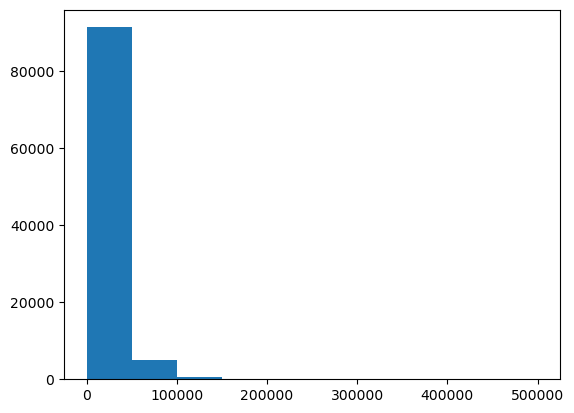

In [84]:
# Retrieving Histogram for checking it is in Normal distribution or not.
plt.hist(df["Profit"])
plt.show()

In [85]:
# We can have a glance on the above histogram as it right skewed(positively skewed)
# As it is not in normal distribution so, we can't use z score.

In [86]:
# Through IQR 
Q1 = df1["Profit"].quantile(0.25)
Q3 = df1["Profit"].quantile(0.75)
print(Q1)
print(Q3)

1830.0749999999998
15043.08


In [87]:
IQR = Q3 -Q1
print(IQR)

13213.005000000001


In [88]:
ub = Q3 + 1.5 * IQR
lb = Q1 - 1.5 * IQR
print(ub)
print(lb)

34862.5875
-17989.4325


In [89]:
# There are no lower outliers.
# Hence the above observation is proving that no profit values below the lower bound

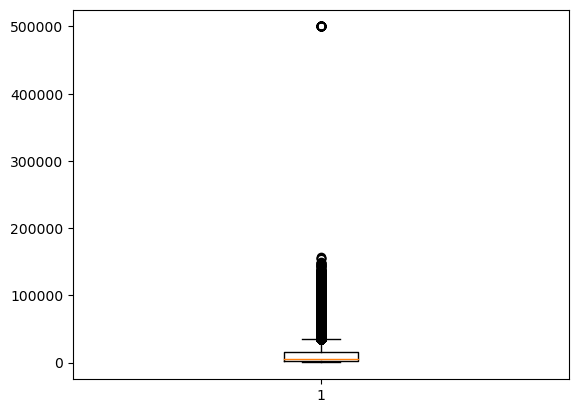

In [90]:
# By checking with boxplot we can easily identify the outliers present in the data.
plt.boxplot(df1["Profit"])
plt.show()

In [91]:
# Calculating number of upper outliers.
df1[df1["Profit"] > ub].shape

(10173, 17)

In [92]:
df1[["Sales","Profit"]].corr()

,Sales,Profit
Sales,1.000000,0.777575
Profit,0.777575,1.000000


In [93]:
# In the above row we've been found correlation between sales and profit.
# And we got the result as 0.77 which indicates strong positive.
# Through this we got to know that if sales is increasing then profit is also increasing. 

# 6️. Standardization

In [94]:
df1["Product_Category"].unique()

array(['Clothing', 'Electronics', 'Furniture'], dtype=object)

In [95]:
df1["Sub_Category"].unique()

array(['Kids', 'Laptop', 'Women', 'Accessories', 'Sofa', 'Chair',
       'Mobile', 'Table', 'Men'], dtype=object)

In [96]:
df1.columns = df1.columns.str.strip() # strip() will remove the extra spaces from the bith the sides

# Phase 2 EDA

###### A.Univariate analysis 

In [97]:
df1["Sales"].describe()

count    100019.000000
mean      51390.325114
std       68889.636437
min         292.000000
25%        7876.350000
50%       21350.300000
75%       63423.775000
max      399965.000000
Name: Sales, dtype: float64

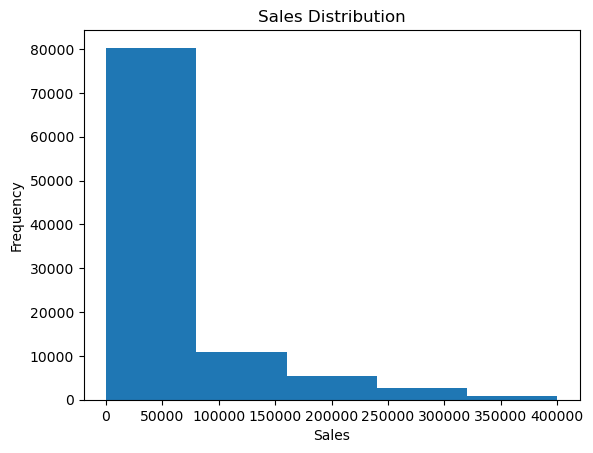

In [98]:
plt.hist(df1["Sales"],bins=5)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [99]:
# By plotting histogram on sales stating that there is right skewed.
# For outlier detection plotting box plot

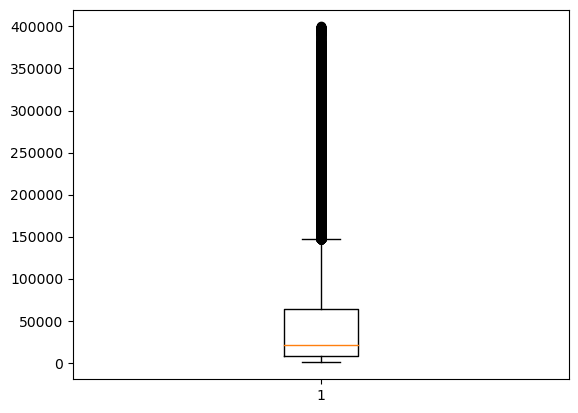

In [100]:
plt.boxplot(df1["Sales"])
plt.show()

In [101]:
# Through IQR 
Q1 = df1["Sales"].quantile(0.25)
Q3 = df1["Sales"].quantile(0.75)

iqr = Q3 - Q1

ub = Q3 + 1.5 * iqr
lb = Q1 - 1.5 * iqr
print(ub)
print(lb)

146744.9125
-75444.7875


In [102]:
Sales_outliers = df1[(df1["Sales"] < lb) | 
                    (df1["Sales"] > ub) ]

In [103]:
Sales_outliers

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
15,16,2022-04-10,2022-04-17,2379,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 110,258922.75,5,0.15,59186.74,500.0,Cash on Delivery,7
16,17,2023-10-26,2023-10-29,4077,Consumer,East,Odisha,Electronics,Laptop,Laptop Product 69,357322.50,5,0.10,97920.08,500.0,Cash on Delivery,3
24,25,2022-07-11,2022-07-12,1149,Corporate,West,Gujarat,Electronics,Accessories,Accessories Product 36,278719.20,4,0.10,73920.24,400.0,Debit Card,1
25,26,2022-10-04,2022-10-05,1412,Consumer,North,Haryana,Electronics,Laptop,Laptop Product 16,239243.25,5,0.05,93913.43,500.0,Cash on Delivery,1
37,38,2023-12-01,2023-12-02,4726,Home Office,East,Odisha,Electronics,Mobile,Mobile Product 64,170107.95,3,0.05,35690.17,300.0,Credit Card,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,99995,2023-06-29,2023-06-30,2392,Home Office,South,Karnataka,Electronics,Laptop,Laptop Product 115,315095.00,5,0.15,54227.67,500.0,UPI,1
99995,99996,2022-02-19,2022-02-23,2316,Consumer,North,Delhi,Electronics,Laptop,Laptop Product 113,229919.00,4,0.05,91932.58,400.0,Debit Card,4
99997,99998,2022-03-29,2022-04-05,4691,Consumer,West,Maharashtra,Electronics,Mobile,Mobile Product 196,171555.00,5,0.00,5101.15,500.0,Debit Card,7
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,400.0,Credit Card,5


In [104]:
df1["Sales"].skew()

2.1263019455101047

In [105]:
# By running the above code we're getting 2.12 as result that means it is HIGHLY SKEWED.

###### Profit

In [106]:
df1["Profit"].describe()

count    100019.000000
mean      12875.161293
std       21462.717972
min          36.040000
25%        1830.075000
50%        5101.150000
75%       15043.080000
max      500000.000000
Name: Profit, dtype: float64

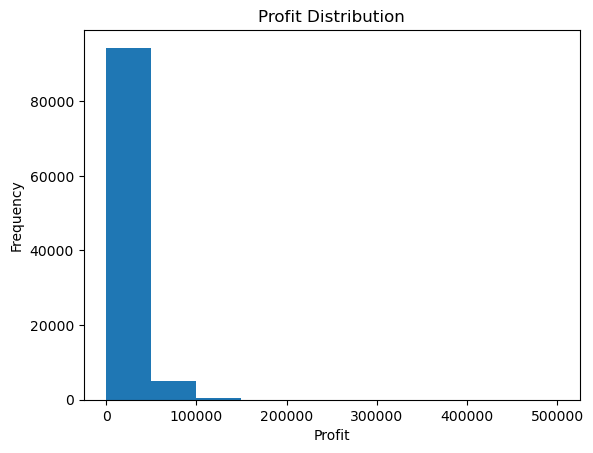

In [107]:
plt.hist(df1["Profit"])
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

In [108]:
# By plotting Histogram we know that there is positively skewed or right skewed.

In [109]:
df1["Profit"].skew()
# Here result of Profit by using skew is 7.53 i.e., Highly skewed.

7.539682045446105

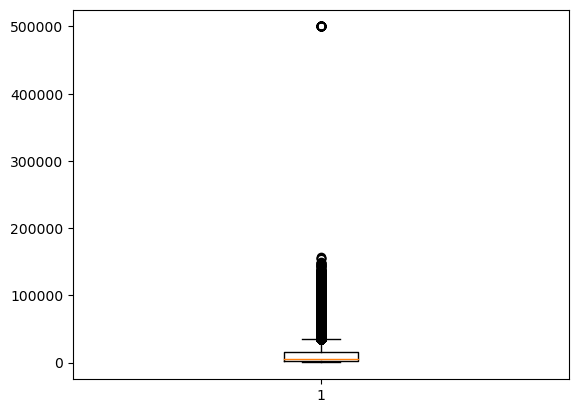

In [110]:
plt.boxplot(df1["Profit"])
plt.show()

In [111]:
# In the above boxplot, the box became small that represents small variations with High value outliers.

In [112]:
# As it is not normally distributed so we're not using z-score, I'm using IQR.

In [113]:
# Through IQR 
Q1 = df1["Profit"].quantile(0.25)
Q3 = df1["Profit"].quantile(0.75)

iqr = Q3 - Q1

ub = Q3 + 1.5 * iqr
lb = Q1 - 1.5 * iqr
print(ub)
print(lb)

34862.5875
-17989.4325


In [114]:
profit_outliers = df1[(df1["Profit"] < lb) | 
                     (df1["Profit"] > ub)]

In [115]:
profit_outliers

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
15,16,2022-04-10,2022-04-17,2379,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 110,258922.75,5,0.15,59186.74,500.0,Cash on Delivery,7
16,17,2023-10-26,2023-10-29,4077,Consumer,East,Odisha,Electronics,Laptop,Laptop Product 69,357322.50,5,0.10,97920.08,500.0,Cash on Delivery,3
24,25,2022-07-11,2022-07-12,1149,Corporate,West,Gujarat,Electronics,Accessories,Accessories Product 36,278719.20,4,0.10,73920.24,400.0,Debit Card,1
25,26,2022-10-04,2022-10-05,1412,Consumer,North,Haryana,Electronics,Laptop,Laptop Product 16,239243.25,5,0.05,93913.43,500.0,Cash on Delivery,1
29,30,2022-01-22,2022-01-24,4959,Corporate,East,Odisha,Electronics,Laptop,Laptop Product 37,65041.20,4,0.10,500000.00,400.0,Cash on Delivery,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99990,99991,2022-01-30,2022-02-01,3757,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 128,186720.60,4,0.05,49466.50,400.0,Cash on Delivery,2
99994,99995,2023-06-29,2023-06-30,2392,Home Office,South,Karnataka,Electronics,Laptop,Laptop Product 115,315095.00,5,0.15,54227.67,500.0,UPI,1
99995,99996,2022-02-19,2022-02-23,2316,Consumer,North,Delhi,Electronics,Laptop,Laptop Product 113,229919.00,4,0.05,91932.58,400.0,Debit Card,4
100067,39851,2023-07-15,2023-07-19,4455,Corporate,North,Delhi,Furniture,Sofa,Sofa Product 166,53473.50,5,0.15,500000.00,500.0,UPI,4


###### Discount

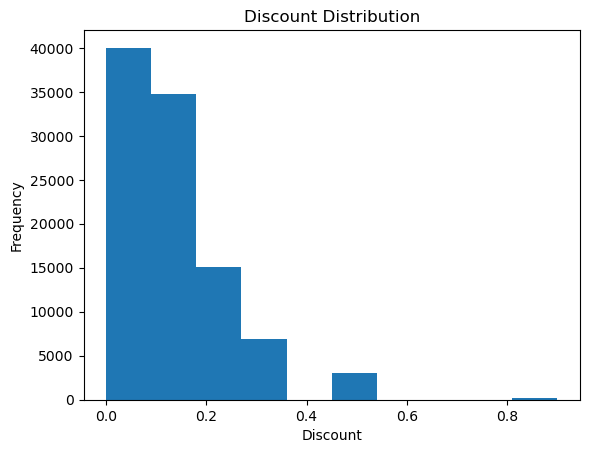

In [116]:
plt.hist(df1["Discount"])
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

In [117]:
df1["Discount"].skew()

1.8341506246954673

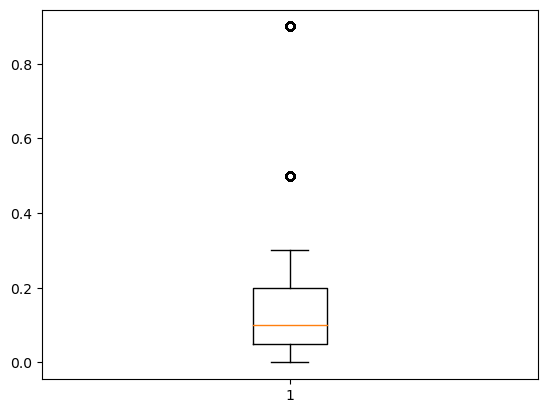

In [118]:
plt.boxplot(df1["Discount"])
plt.show()

In [119]:
# Through IQR 
Q1 = df1["Discount"].quantile(0.25)
Q3 = df1["Discount"].quantile(0.75)

iqr = Q3 - Q1

ub = Q3 + 1.5 * iqr
lb = Q1 - 1.5 * iqr
print(ub)
print(lb)

0.42500000000000004
-0.17500000000000004


In [120]:
discount_outliers = df1[(df1["Discount"] < lb) | 
                     (df1["Discount"] > ub)]

In [121]:
discount_outliers


,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
11,12,2022-11-27,2022-12-02,3980,Home Office,South,Karnataka,Furniture,Sofa,Sofa Product 169,12032.0,2,0.5,1333.79,200.0,UPI,5
85,86,2023-12-03,2023-12-10,2898,Corporate,South,Telangana,Furniture,Chair,Chair Product 167,16691.0,2,0.5,1972.75,200.0,Cash on Delivery,7
165,166,2023-07-10,2023-07-11,3800,Corporate,East,West Bengal,Electronics,Laptop,Laptop Product 102,87045.0,5,0.5,32652.51,500.0,Credit Card,1
243,244,2022-11-22,2022-11-27,4026,Home Office,North,Punjab,Furniture,Chair,Chair Product 175,5266.5,1,0.5,1570.61,100.0,Credit Card,5
317,318,2023-04-15,2023-04-19,4663,Consumer,South,Telangana,Furniture,Sofa,Sofa Product 126,8757.0,2,0.5,2752.14,200.0,Debit Card,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99917,99918,2022-06-03,2022-06-06,2074,Corporate,East,Odisha,Electronics,Accessories,Accessories Product 181,60104.0,4,0.5,17021.24,400.0,Cash on Delivery,3
100009,609,2023-01-28,2023-02-02,1572,Corporate,East,Bihar,Furniture,Sofa,Sofa Product 130,49047.6,4,0.9,7961.32,400.0,Cash on Delivery,5
100095,75591,2023-06-19,2023-06-21,3350,Consumer,East,Odisha,Furniture,Table,Table Product 165,29772.8,4,0.9,5886.19,400.0,Credit Card,2
100196,52971,2022-10-26,2022-10-28,1311,Consumer,South,Telangana,Furniture,Sofa,Sofa Product 192,25622.4,4,0.9,4272.50,400.0,UPI,2


###### Quantity

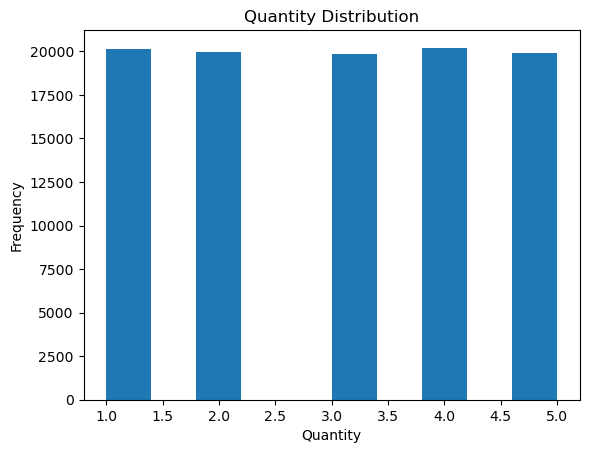

In [122]:
plt.hist(df1["Quantity"])
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

In [123]:
df1["Quantity"].skew()
# By checking skewness it resulted as close to zero, so it is symmetry.

-0.0008996495905767978

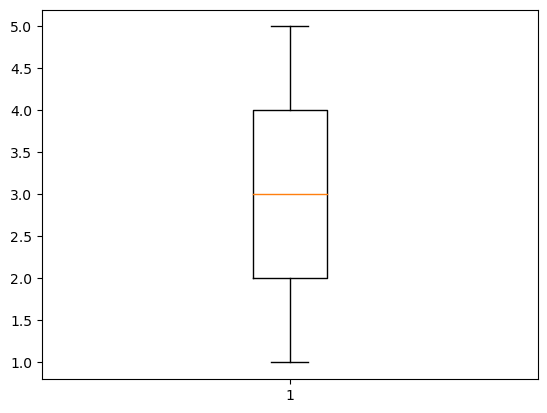

In [124]:
plt.boxplot(df1["Quantity"])
plt.show()

In [125]:
# There are no outliers in Quantity.

On Quantity I've applied histogram for finding normal distribution and it resulted normally. 
So later on checked skewness of quantity it is close to zero, then it will be symmetry.
Then Boxplot for finding outliers plotted box plot, By having a glance on the plot came to a conclusion that there are no outliers.

###### Shipping Cost

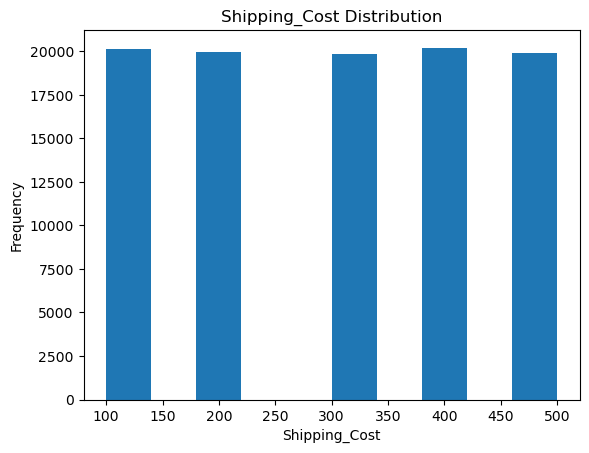

In [126]:
plt.hist(df1["Shipping_Cost"])
plt.title("Shipping_Cost Distribution")
plt.xlabel("Shipping_Cost")
plt.ylabel("Frequency")
plt.show()

In [127]:
df1["Shipping_Cost"].skew()

-0.0008996495905775299

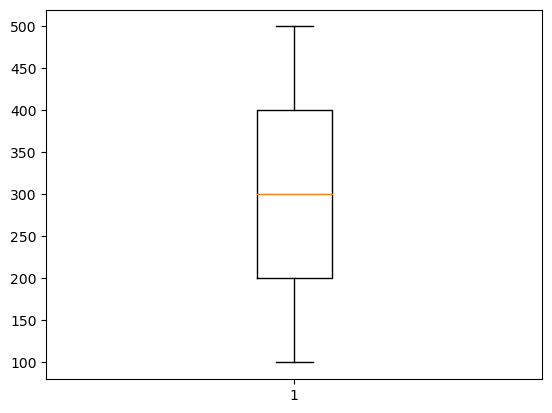

In [128]:
plt.boxplot(df1["Shipping_Cost"])
plt.show()

In [129]:
# By plotting histogram we got to know that the data is distributed normally. 
# In boxplot there are no outliers present in it.

In [130]:
df1

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Segment,Region,State,Product_Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit,Shipping_Cost,Payment_Mode,Delivery_time
0,1,2022-04-13,2022-04-14,1992,Consumer,East,Odisha,Clothing,Kids,Kids Product 3,14492.00,5,0.20,1621.85,500.0,Cash on Delivery,1
1,2,2023-03-12,2023-03-13,4347,Corporate,East,Bihar,Electronics,Laptop,Laptop Product 100,47633.00,1,0.05,5774.48,100.0,Cash on Delivery,1
2,3,2022-09-28,2022-10-04,2195,Corporate,West,Maharashtra,Clothing,Women,Women Product 1,4058.10,1,0.10,521.04,100.0,Credit Card,6
3,4,2022-04-17,2022-04-21,3425,Consumer,South,Tamil Nadu,Electronics,Laptop,Laptop Product 139,61980.00,4,0.00,6695.36,400.0,Cash on Delivery,4
4,5,2022-03-13,2022-03-20,2967,Consumer,North,Haryana,Clothing,Women,Women Product 50,6807.00,3,0.00,2653.83,300.0,Debit Card,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100426,15250,2022-05-29,2022-06-03,2724,Home Office,East,Odisha,Electronics,Laptop,Laptop Product 84,196697.60,4,0.20,22662.63,400.0,Credit Card,5
100439,95690,2023-10-30,2023-10-31,2827,Home Office,East,Bihar,Electronics,Accessories,Accessories Product 127,95900.00,2,0.00,24250.98,200.0,Cash on Delivery,1
100451,50989,2023-11-24,2023-12-01,3617,Corporate,South,Telangana,Electronics,Mobile,Mobile Product 91,129405.00,3,0.00,22012.66,300.0,UPI,7
100455,98393,2022-05-30,2022-06-05,2251,Corporate,North,Haryana,Electronics,Mobile,Mobile Product 3,272293.25,5,0.15,50069.21,500.0,Credit Card,6


# B. Categorical Analysis

###### Sales by Region

In [131]:
sales_by_region = df1.groupby("Region")["Sales"].sum()

In [132]:
sales_by_region

Region
East     1.281431e+09
North    1.312996e+09
South    1.259473e+09
West     1.286109e+09
Name: Sales, dtype: float64

###### Sales by Customer Segment

In [133]:
sales_by_customer_segment = df1.groupby("Customer_Segment")["Sales"].sum()

In [134]:
sales_by_customer_segment

Customer_Segment
Consumer       1.822707e+09
Corporate      1.674988e+09
Home Office    1.642314e+09
Name: Sales, dtype: float64

###### Sales by Product Category

In [135]:
sales_by_product_category = df1.groupby("Product_Category")["Sales"].sum()

In [136]:
sales_by_product_category

Product_Category
Clothing       2.443130e+08
Electronics    3.928688e+09
Furniture      9.670077e+08
Name: Sales, dtype: float64

###### Top 10 Products by Sales

In [137]:
# Here for retrieving the top 10 products by sales 

In [138]:
top_products = (
    df1.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10))

In [139]:
df1[["Product_Category","Sales"]].sort_values(by="Sales",ascending=False).head(10)

,Product_Category,Sales
18871,Electronics,399965.0
40781,Electronics,399935.0
45423,Electronics,399305.0
59936,Electronics,399285.0
29910,Electronics,399075.0
8381,Electronics,399020.0
57974,Electronics,398775.0
39968,Electronics,398750.0
35308,Electronics,398750.0
69217,Electronics,398670.0


Top 10 States by Revenue

In [140]:
df1.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

State
Punjab         4.445121e+08
Haryana        4.349792e+08
Gujarat        4.342799e+08
Delhi          4.335050e+08
Odisha         4.313530e+08
Rajasthan      4.297788e+08
Telangana      4.291378e+08
West Bengal    4.273218e+08
Karnataka      4.264790e+08
Bihar          4.227561e+08
Name: Sales, dtype: float64

# C. Bivariate Analysis

Analysing relationships

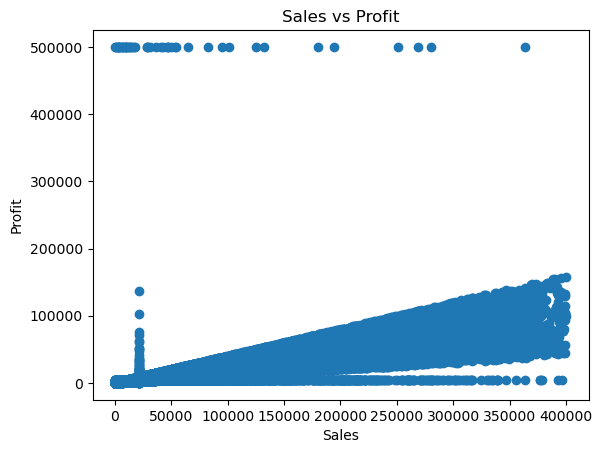

In [141]:
plt.scatter(df1["Sales"], df1["Profit"])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

In [142]:
df1["Sales"].corr(df1["Profit"])

0.7775747753015407

In [143]:
# The above step ensures that there is strong positive correlation between sales and profit.
# Higher sales leads to higher profits.
# Through the result Sales is directly proportional to the Profit.

Discount vs Profit

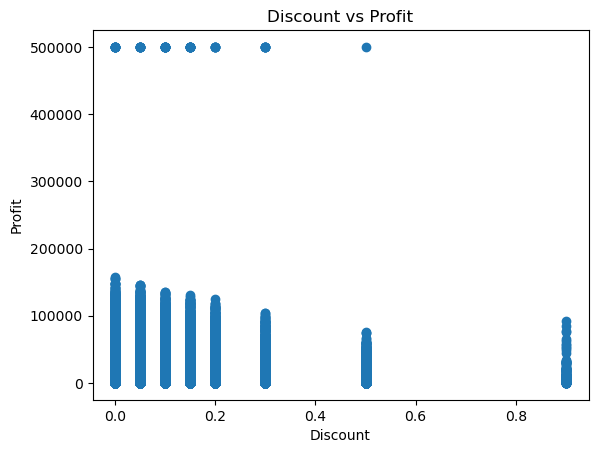

In [144]:
plt.scatter(df1["Discount"], df1["Profit"])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

In [145]:
df1["Discount"].corr(df1["Profit"])

-0.06664742729456881

In [146]:
# By plotting scatter plot between discount and profit then correlation, it results as -0.066
# As the result is negative(left skewed), there will be more larger values and very few small values.
# This represents Discount is inversely proportional to Profit, this indicates relationship is extremely weak.

Shipping Cost vs Profit

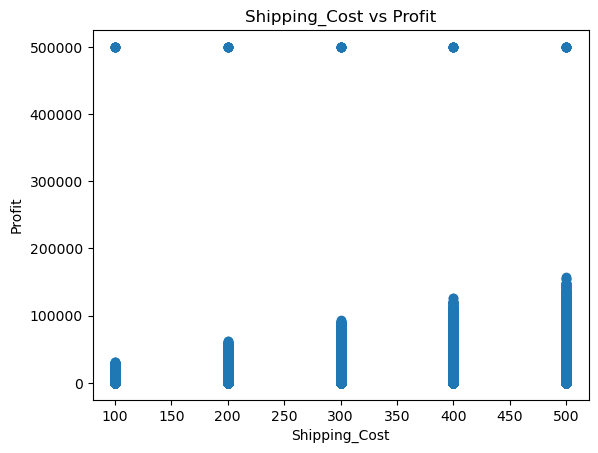

In [147]:
plt.scatter(df1["Shipping_Cost"], df1["Profit"])
plt.xlabel("Shipping_Cost")
plt.ylabel("Profit")
plt.title("Shipping_Cost vs Profit")
plt.show()

In [148]:
df1["Shipping_Cost"].corr(df1["Profit"])

0.27145565474292116

In [149]:
# Relationship between Shipping cost and profit is weak positive relationship.
# This indicates if there increase in shipping cost then there will be a slight increase in profit.

Category vs Profit

In [150]:
category_profit = df1.groupby("Product_Category")["Profit"].sum().sort_values(ascending=False)
category_profit

Product_Category
Electronics    9.663464e+08
Furniture      2.495716e+08
Clothing       7.184274e+07
Name: Profit, dtype: float64

In [151]:
df1.groupby("Product_Category")["Profit"].mean()

Product_Category
Clothing        2141.618638
Electronics    29055.186215
Furniture       7514.047697
Name: Profit, dtype: float64

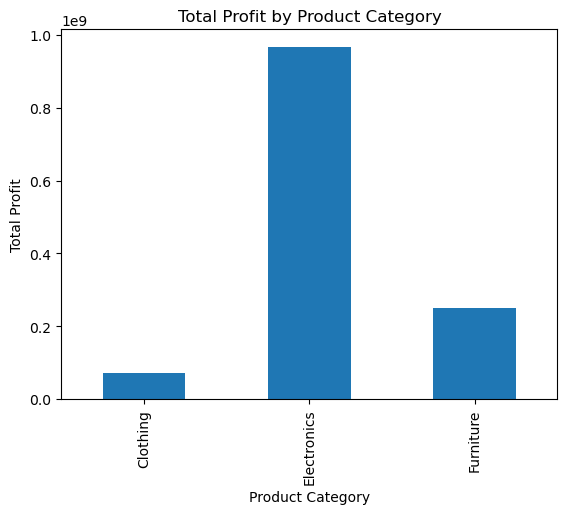

In [152]:
df1.groupby("Product_Category")["Profit"].sum().plot(kind="bar")

plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")
plt.show()

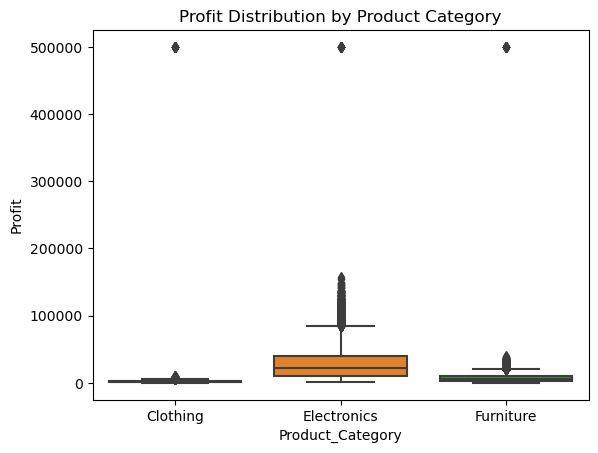

In [153]:
import seaborn as sns

sns.boxplot(x="Product_Category", y="Profit", data=df1)

plt.title("Profit Distribution by Product Category")
plt.show()

In [154]:
# First I've analyzed sum and mean of product category and profit by using aggregate functions.
# Then i plotted bar plot is for which category is having more profit and box plot for understanding outliers.

Region vs Profit

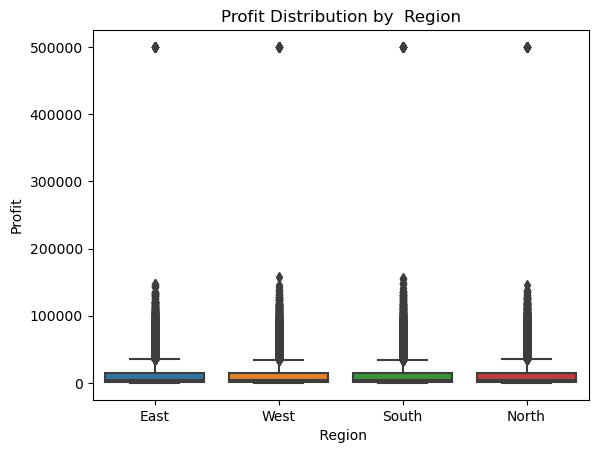

In [155]:
import seaborn as sns


sns.boxplot(x="Region", y="Profit", data=df1)

plt.title("Profit Distribution by  Region")
plt.xlabel(" Region")
plt.ylabel("Profit")

plt.show()

In [156]:
# I've represented boxplots between region and profit.
# On both average and sum in both the results there are  outliers.

###### Does a high discount reduce profit?

# D. Time-Based Analysis

Monthly Sales Trend

In [157]:
df1["Year_Month"] = df1["Order_Date"].dt.to_period("M") # it represents monthly period of interval

In [158]:
monthly_sales = df1.groupby("Year_Month")["Sales"].sum() # Monthly sales are grouping.

In [159]:
monthly_sales

Year_Month
2021-12    3.155856e+05
2022-01    2.183978e+08
2022-02    1.911239e+08
2022-03    2.179010e+08
2022-04    2.121170e+08
2022-05    2.114356e+08
2022-06    2.247081e+08
2022-07    2.092452e+08
2022-08    2.201835e+08
2022-09    2.066573e+08
2022-10    2.141838e+08
2022-11    2.040005e+08
2022-12    2.265618e+08
2023-01    2.247293e+08
2023-02    1.947583e+08
2023-03    2.169327e+08
2023-04    2.164085e+08
2023-05    2.247589e+08
2023-06    2.134449e+08
2023-07    2.221757e+08
2023-08    2.129441e+08
2023-09    2.088286e+08
2023-10    2.242426e+08
2023-11    2.029200e+08
2023-12    2.210343e+08
Freq: M, Name: Sales, dtype: float64

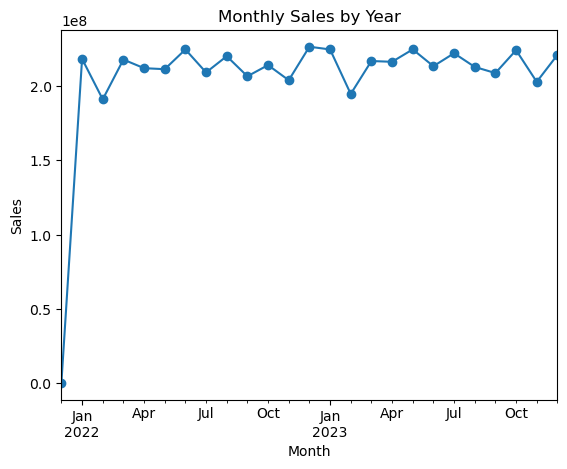

In [160]:
monthly_sales.T.plot(marker="o")

plt.title("Monthly Sales by Year")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [161]:
# In Monthly sales trend the above line chart is explaining the monthly sales this is with the function of dt.to_period("M")

Quarterly revenue growth


In [162]:
quarterly_sales = df1.groupby(df1["Order_Date"].dt.to_period("Q"))["Sales"].sum()

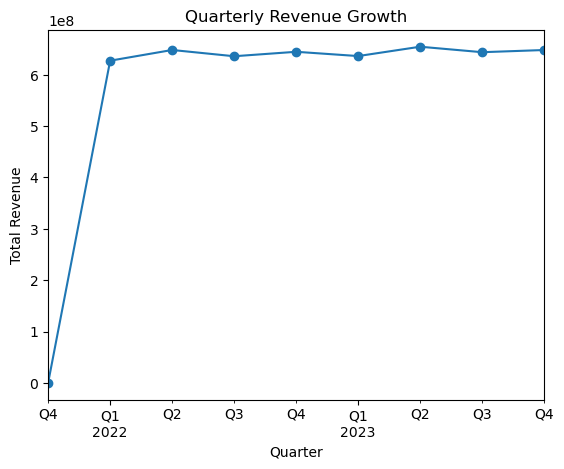

In [163]:
quarterly_sales.plot(kind="line", marker = "o")
plt.title("Quarterly Revenue Growth")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue")
plt.show()

In [164]:
# In quarterly revenue growth I took dt.to_period where it can retrieve period of sales and.
#I plotted both the plots for understanding of in which quarter how much sales have been done.

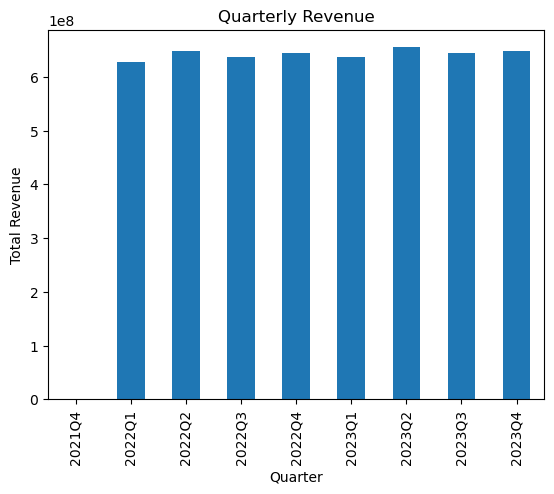

In [165]:
quarterly_sales.plot(kind="bar")
plt.title("Quarterly Revenue")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue")
plt.show()

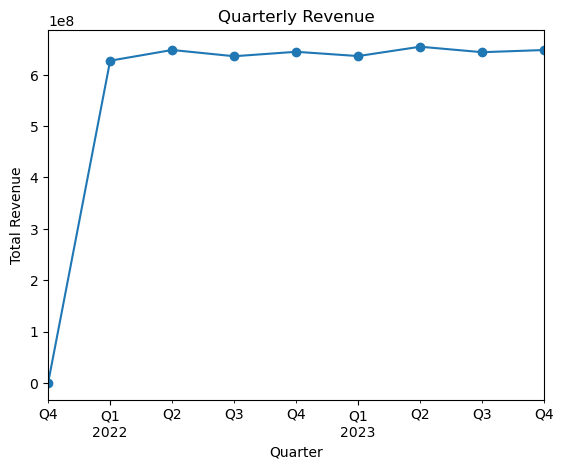

In [166]:
quarterly_sales.plot(kind="line",marker="o")
plt.title("Quarterly Revenue")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue")
plt.show()

Seasonal Patterns

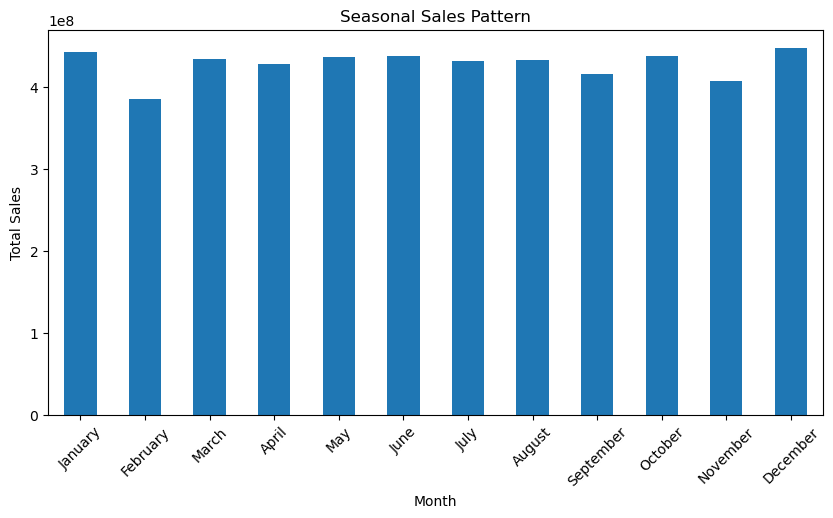

In [167]:
seasonal_sales = df1.groupby(df1["Order_Date"].dt.month_name())["Sales"].sum()

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

seasonal_sales = seasonal_sales.reindex(month_order)

seasonal_sales.plot(kind="bar", figsize=(10,5))

plt.title("Seasonal Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

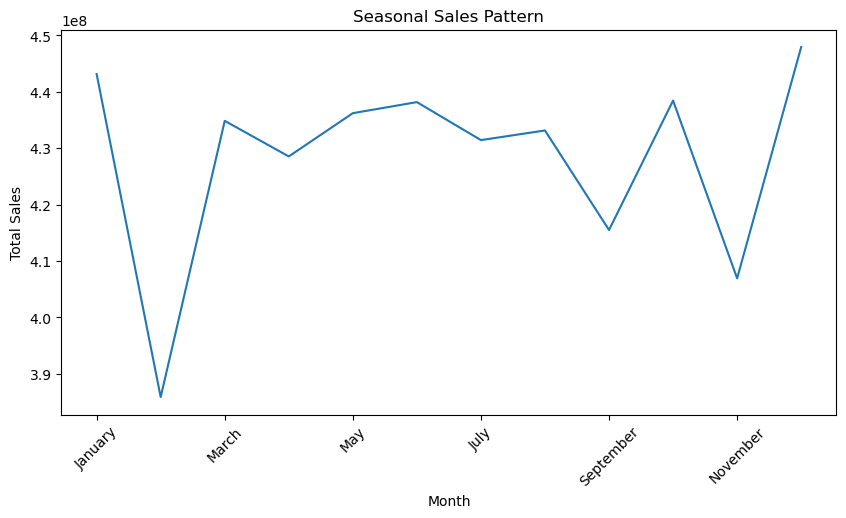

In [168]:
seasonal_sales.plot(kind="line", figsize=(10,5))

plt.title("Seasonal Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [169]:
# Here's a bar chart representing seasonal patterns for each month sales. 

Best & Worst Performing Months

In [170]:
monthly_sales = df1.groupby(df1["Order_Date"].dt.month)["Sales"].sum().sort_index()

In [171]:
best_month_num = monthly_sales.idxmax()
worst_month_num = monthly_sales.idxmin()

best_sales = monthly_sales.max()
worst_sales = monthly_sales.min()

print("Best Month :", best_month_num, "-", best_sales)
print("Worst Month :", worst_month_num, "-", worst_sales)

Best Month : 12 - 447911728.55
Worst Month : 2 - 385882153.15


In [172]:
# Here comes the best and worst month sales which is december and february with values 
#Best Month : 12 - 447911728.55
#Worst Month : 2 - 385882153.15

# E. Customer Analysis

Top 20% customers revenue contribution (Pareto Analysis)

In [173]:
customer_sales = df1.groupby("Customer_ID")["Sales"].sum().sort_values(ascending=False)

top_20 = customer_sales.head(int(len(customer_sales)*0.2))

print((top_20.sum()/customer_sales.sum()) * 100)

29.841609746312226


In [174]:
# In the top 20% customers revenue contribution first i grouped Customerid and sales sum of all grouped values and sorted according to descending values for top values.
# Again I've took Customer sales top 20% by taking length.
# In the final I've printed top20 customer's sum by customer sales * 100 for percentage 
# Hence final verdict is top 20% customers contribute 29.84% of total sales.

Repeat customer behavior

In [175]:
customers_orders = df1.groupby("Customer_ID")["Order_ID"].nunique()

In [176]:
repeat_customers = customers_orders[customers_orders > 1]

In [177]:
print("Repeat Customers:", len(repeat_customers))

Repeat Customers: 4000


In [178]:
repeat_rate = (len(repeat_customers) / len(customers_orders)) * 100

In [179]:
repeat_rate

100.0

In [180]:
# First I've grouped both customer id and order id for getting unique customers.
# Then I've checked customers who placed more than one order.
# Here nunique will represents the number of unique values present in it.
# Printed repeated customers using length function.
# There are 4000 repeated customers.
# Repeat rate is 100%.

Average order value per segment

In [181]:
segment_sales = df1.groupby("Customer_Segment")["Sales"].sum()

In [182]:
segment_orders = df1.groupby("Customer_Segment")["Order_ID"].nunique()

In [183]:
aov = segment_sales / segment_orders

In [184]:
aov

Customer_Segment
Consumer       51368.457154
Corporate      52121.866282
Home Office    50718.435735
dtype: float64

In [185]:
# In the very first step I grouped customer segment with sales and got their sum.
# Next grouping with Customer segemnt with order id for retrieving number of unique orders.
# Then average order value with segment sales / segment orders which results as
# Customer_Segment
# Consumer       51368.457154
# Corporate      52121.866282
# Home Office    50718.435735

# F. Correlation Analysis

###### Correlation matrix

In [186]:
corr_matrix = df1.corr(numeric_only=True)
corr_matrix

,Order_ID,Customer_ID,Sales,Quantity,Discount,Profit,Shipping_Cost,Delivery_time
Order_ID,1.000000,0.001256,-0.000177,0.000479,-0.000855,0.000163,0.000479,-0.004146
Customer_ID,0.001256,1.000000,0.002401,0.004804,-0.001936,0.004610,0.004804,-0.000017
Sales,-0.000177,0.002401,1.000000,0.349222,-0.085803,0.777575,0.349222,-0.004483
Quantity,0.000479,0.004804,0.349222,1.000000,-0.001165,0.271456,1.000000,0.000743
Discount,-0.000855,-0.001936,-0.085803,-0.001165,1.000000,-0.066647,-0.001165,-0.001298
Profit,0.000163,0.004610,0.777575,0.271456,-0.066647,1.000000,0.271456,-0.006199
Shipping_Cost,0.000479,0.004804,0.349222,1.000000,-0.001165,0.271456,1.000000,0.000743
Delivery_time,-0.004146,-0.000017,-0.004483,0.000743,-0.001298,-0.006199,0.000743,1.000000


###### Identify strong relationships

In [187]:
# Strong Relationship(0.7-0.9)
#Sales & Profit containing correlation as 0.777 

In [188]:
# Moderate Relationships(0.3-0.7)
# Sales & Quantity  0.349
# Sales & Shipping_Cost  0.349

In [189]:
# Weak/No Relationship(0-0.3)
# Profit & Quantity  0.271
# Profit & Shipping_Cost 0.271

In [190]:
# Remaining values are like (0.00/-0.00) values are considered as zero correlation or no relationship.

# PHASE 3 – BUSINESS INSIGHTS

###### 1. Which region is most profitable?

In [191]:
profitable_reg = df1.groupby("Region")["Profit"].mean()

In [192]:
print(profitable_reg)

Region
East     12948.052224
North    12997.929201
South    12759.156270
West     12794.101451
Name: Profit, dtype: float64


In [193]:
# Here in the above code results East is the more profitable region with 12948.05 .

###### 2. Which product category should be promoted?

In [194]:
promote_pro = df1.groupby("Product_Category")["Sales"].min()

In [195]:
promote_pro

Product_Category
Clothing        292.0
Electronics    5085.0
Furniture      1140.5
Name: Sales, dtype: float64

In [196]:
promote_prod = df1.groupby("Product_Category")["Profit"].min()

In [197]:
promote_prod

Product_Category
Clothing        36.04
Electronics    535.08
Furniture      156.65
Name: Profit, dtype: float64

In [198]:
# # Clothing should be promoted more due to less sales and less profit.

###### 3. Is discount strategy hurting profitability?

In [199]:
df1.groupby("Discount")["Profit"].mean()

Discount
0.00    14632.519277
0.05    13637.574782
0.10    13114.669493
0.15    12516.857591
0.20    11787.240072
0.30    10423.543751
0.50     7653.676381
0.90    10930.614500
Name: Profit, dtype: float64

In [200]:
high_discount = df1[df1["Discount"] > 0.8]
high_discount[["Sales","Profit"]].describe()

,Sales,Profit
count,200.000000,200.000000
mean,43288.953750,10930.614500
std,58922.316613,16252.973773
min,689.000000,186.930000
25%,6488.000000,1607.560000
50%,19507.625000,4668.160000
75%,52681.800000,12121.987500
max,330573.500000,92547.300000


In [201]:
# Yes, Profit is hurting by discount strategy.

###### 4. Which customer segment generates most revenue?

In [202]:
segment_sales = df1.groupby("Customer_Segment")["Sales"].sum().sort_values(ascending=False)

In [203]:
segment_sales

Customer_Segment
Consumer       1.822707e+09
Corporate      1.674988e+09
Home Office    1.642314e+09
Name: Sales, dtype: float64

In [204]:
# Consumer segment is generating most revenue.

###### 5. Is shipping cost impacting margins?

In [205]:
df1[["Shipping_Cost", "Profit"]].corr()

,Shipping_Cost,Profit
Shipping_Cost,1.000000,0.271456
Profit,0.271456,1.000000


In [206]:
(df1["Profit"] / df1["Sales"]).corr(df1["Shipping_Cost"])

-0.008653012307907236

In [207]:
# As per the correlation matrix shipping cost is not at all impacting profit.
# Margin is also lying at -0.0086

###### 6. Identify 5 actionable business recommendations.

###### 1.Improve Low-Performing Product Categories

Identify categories with low profit or low sales and review pricing, cost structure, or marketing strategy.

##### 2.Leverage High-Revenue Customer Segments

Focus targeted marketing campaigns on the customer segment generating the highest revenue. Personalized promotions and exclusive benefits can increase their lifetime value.

###### 3. Optimize Discount Strategy
 Avoid excessive discounts (>50%) as they significantly reduce profitability.

###### 4.Enhance Data Monitoring and Reporting

Establish regular performance tracking dashboards for sales, profit, discount, and customer metrics. Continuous monitoring helps in faster decision-making and early problem detection.

###### 5. Control Shipping Costs
 Negotiate better logistics contracts or introduce minimum order value for free shipping to protect margins.

# PHASE 4 – VISUALIZATION REQUIREMENTS

###### Minimum 15 meaningful visualizations

In [208]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

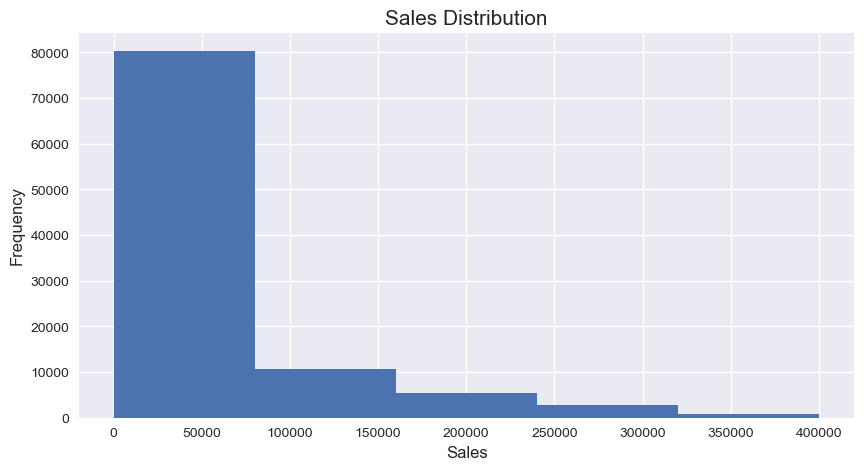

In [209]:
plt.hist(df1["Sales"],bins=5)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [210]:
# By plotting histogram on sales stating that there is right skewed.

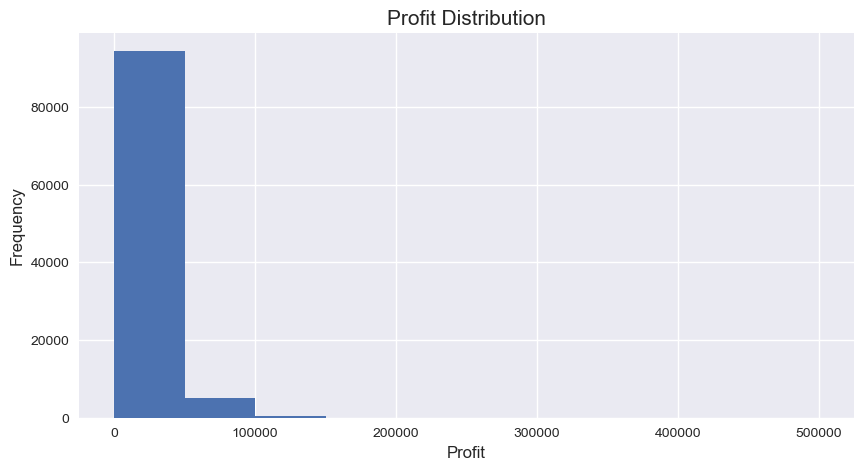

In [211]:
plt.hist(df1["Profit"])
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

In [212]:
# By plotting Histogram we know that profit is positively skewed or right skewed.

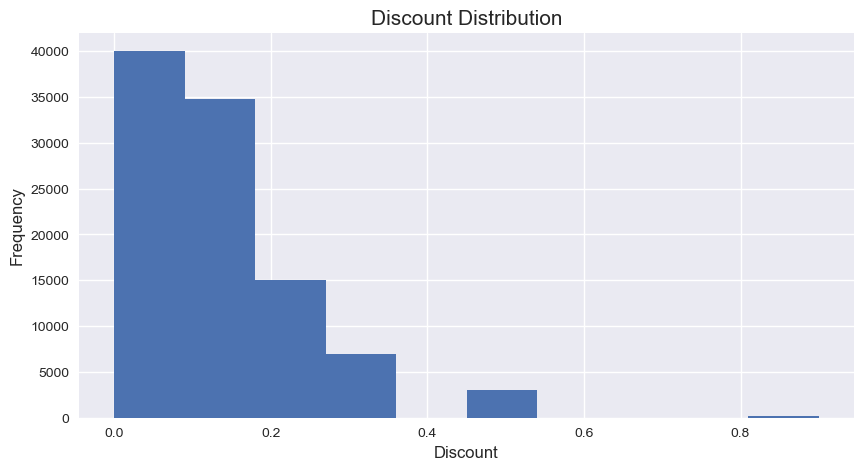

In [213]:
plt.hist(df1["Discount"])
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

In [214]:
# Here's the discount histogram, it is for checking whether the graph is in normal distribution or not.
# After plotting it is in right skewed.

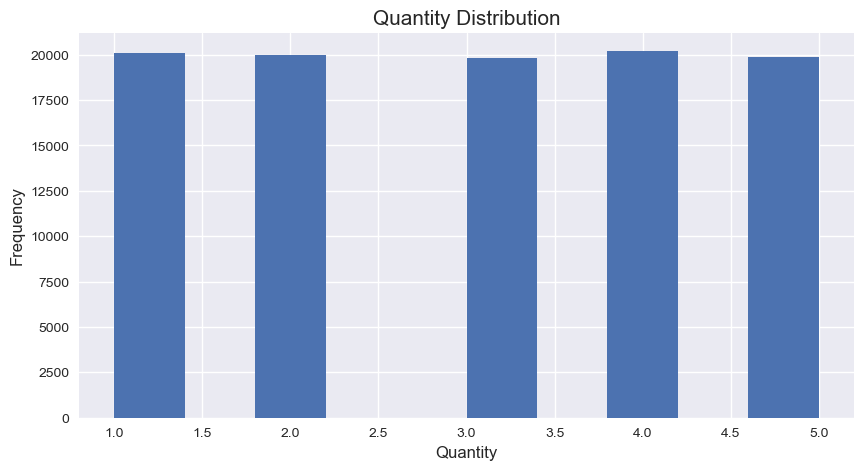

In [215]:
plt.hist(df1["Quantity"])
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

In [216]:
# On Quantity I've applied histogram for finding normal distribution and it resulted normally. 

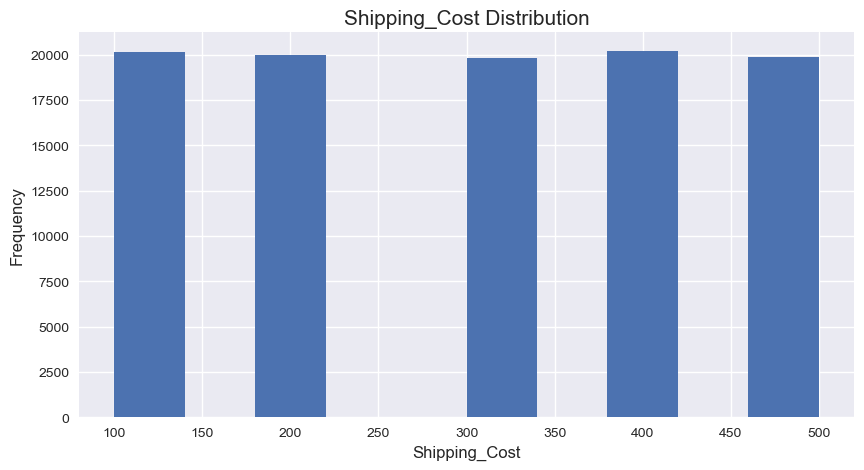

In [217]:
plt.hist(df1["Shipping_Cost"])
plt.title("Shipping_Cost Distribution")
plt.xlabel("Shipping_Cost")
plt.ylabel("Frequency")
plt.show()

In [218]:
# By plotting histogram we got to know that Shipping cost is distributed normally. 

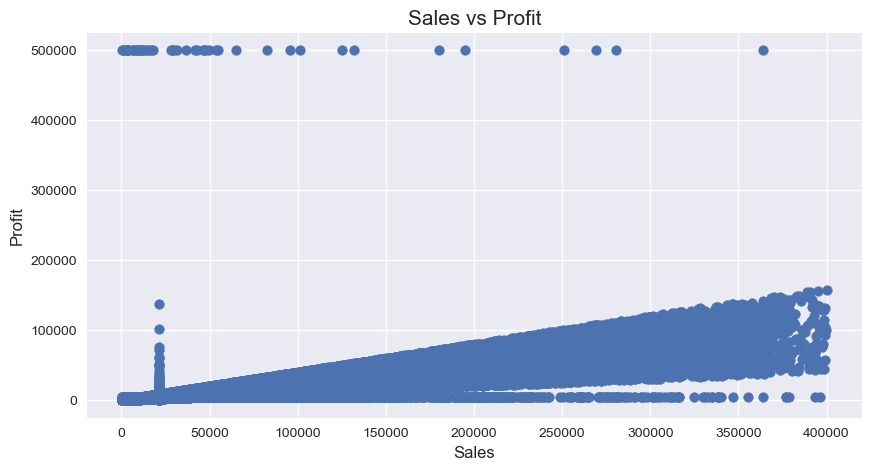

In [219]:
plt.scatter(df1["Sales"], df1["Profit"])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

In [220]:
# The above step ensures that there is strong positive correlation between sales and profit.
# Higher sales leads to higher profits.
# Through the result Sales is directly proportional to the Profit.

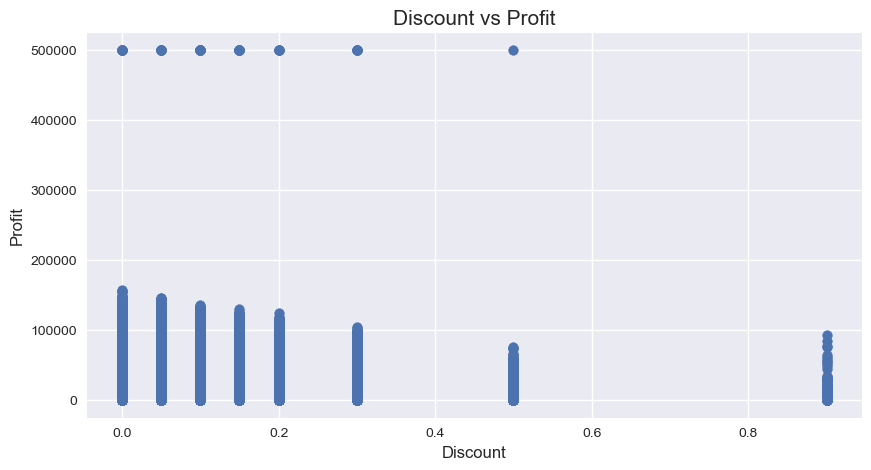

In [221]:
plt.scatter(df1["Discount"], df1["Profit"])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

In [222]:
# By plotting scatter plot between discount and profit then correlation, it results as -0.066
# As the result is negative(left skewed), there will be more larger values and very few small values.
# This represents Discount is inversely proportional to Profit, this indicates relationship is extremely weak.

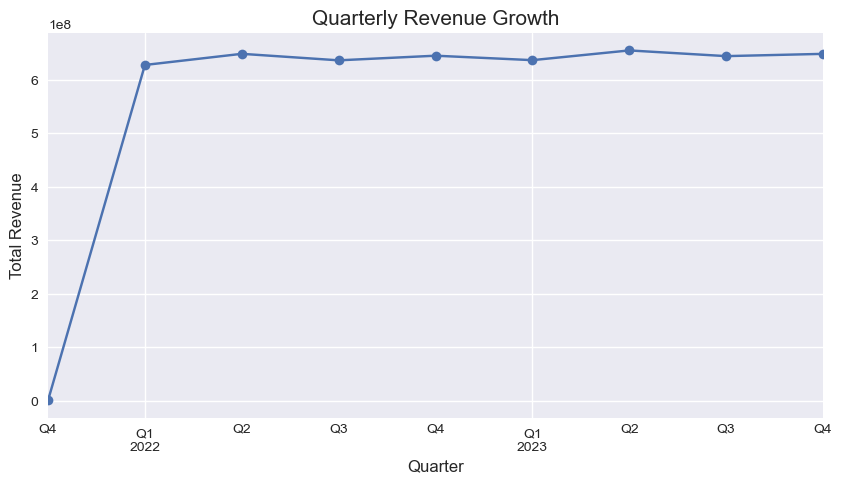

In [223]:
quarterly_sales.plot(kind="line", marker = "o")
plt.title("Quarterly Revenue Growth")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue")
plt.show()

In [224]:
# In quarterly revenue growth I took dt.to_period where it can retrieve period of sales and.
#I plotted both the plots for understanding of in which quarter how much sales have been done.

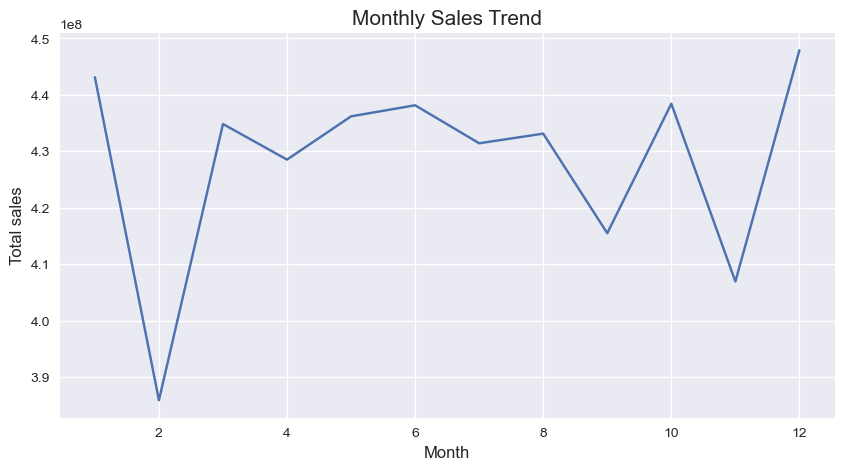

In [225]:
monthly_sales.plot(kind="line")
plt.xlabel("Month")
plt.ylabel("Total sales")
plt.title("Monthly Sales Trend")
plt.show()

In [226]:
# In monthly sales I've been retrieved month by dt.to_month and get their sum through the sum i've plotted line plot for better understanding.

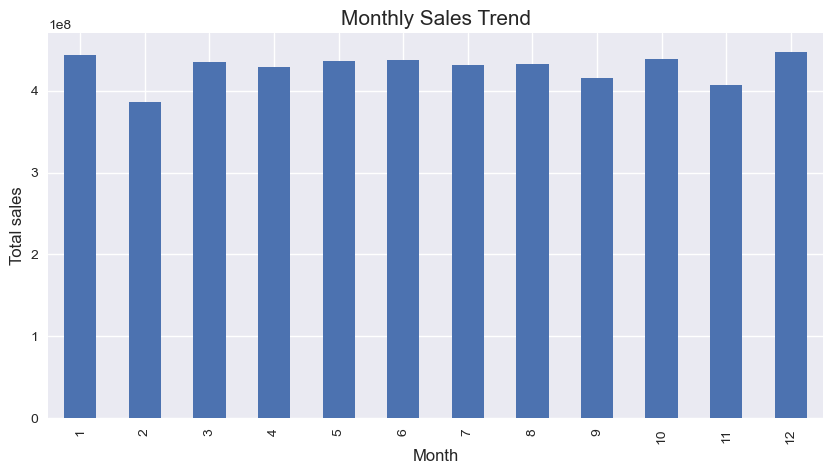

In [227]:
monthly_sales.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Total sales")
plt.title("Monthly Sales Trend")
plt.show()

In [228]:
# In monthly sales I've been retrieved month by dt.to_month and get their sum through the sum i've plotted bar plots for better understanding.

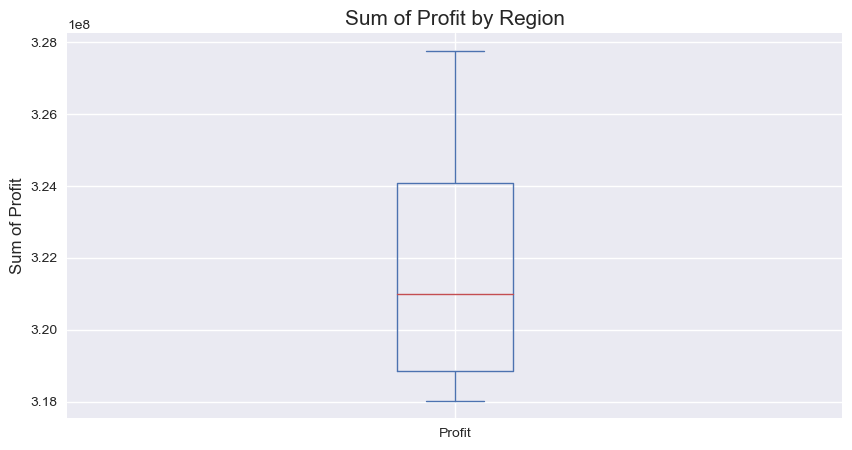

In [229]:
df1.groupby("Region")["Profit"].sum().plot(kind="box")
plt.ylabel("Sum of Profit")
plt.title("Sum of Profit by Region")
plt.show()

In [230]:
# I've represented boxplots between region and profit.
# On  sum  this results there are no outliers.

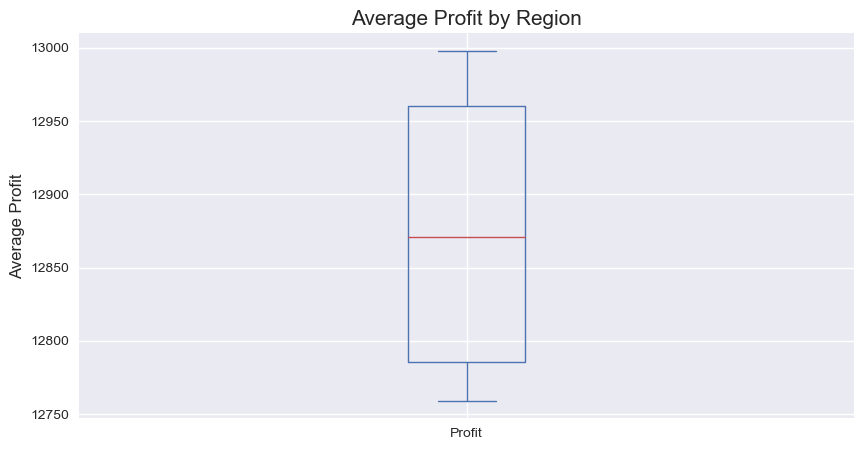

In [231]:
df1.groupby("Region")["Profit"].mean().plot(kind="box")
plt.ylabel("Average Profit")
plt.title("Average Profit by Region")
plt.show()

In [232]:
# I've represented boxplots between region and profit.
# By using  average this results there are no outliers.

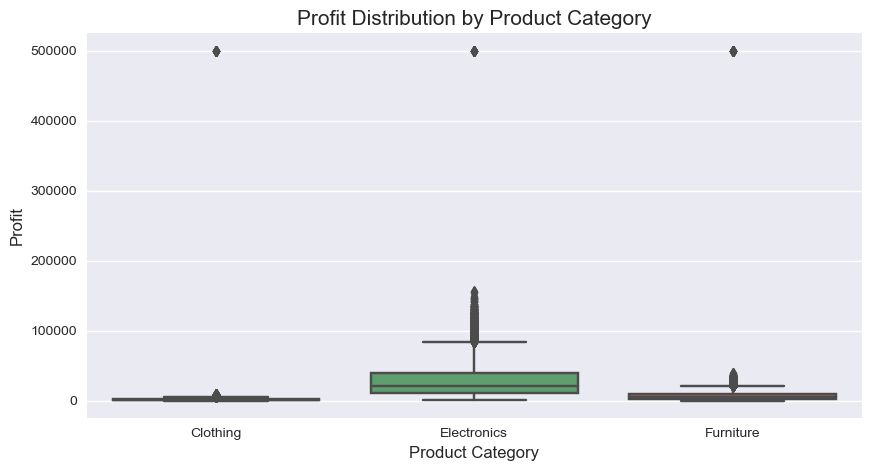

In [233]:
import seaborn as sns


sns.boxplot(x="Product_Category", y="Profit", data=df1)

plt.title("Profit Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit")

plt.show()

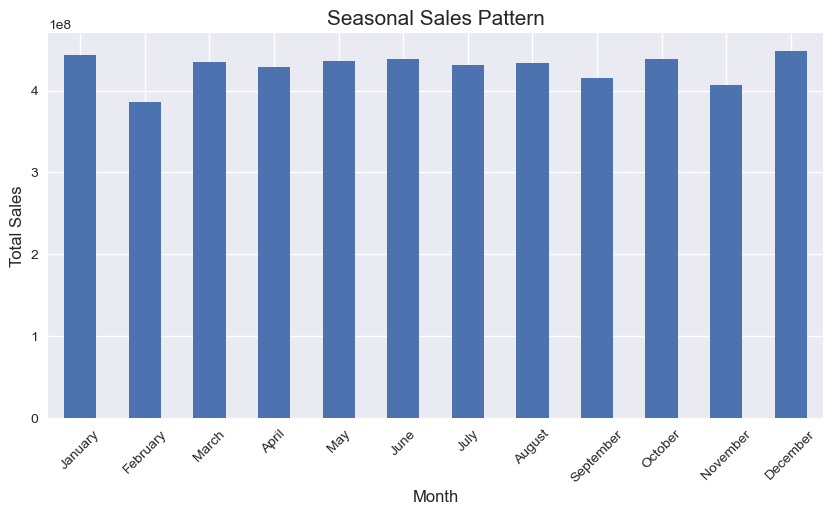

In [234]:
seasonal_sales.plot(kind="bar", figsize=(10,5))

plt.title("Seasonal Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [235]:
# Here's a bar chart representing seasonal patterns for each month sales. 

In [240]:
final_df = df1.drop("Year_Month", axis=1)
final_df.to_excel("cleaned_dataset.xlsx", index=False)